# RoomBeacon — Auditable Bronze-to-Silver Processing Report

This executable report explains the canonical helper without duplicating it. Runtime evidence shows rules, lineage, before/after values, unresolved conditions, quality gates, and publication results.

**Canonical Silver dataset:** `data/silver/rental_listings.parquet`  
**Metadata:** `data/silver/rental_listings.metadata.json`  
**DuckDB role:** analytical/query engine; no physical Silver table is required for persistence.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import sys
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'crawler').is_dir() and (p/'analytics').is_dir())
sys.path.insert(0, str(PROJECT_ROOT))
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT/'.env', override=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import duckdb
from analytics.bronze.snapshot import load_bronze_snapshot
from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.silver_processing import build_silver_dataset, evaluate_pre_silver_quality_gate
from notebooks.utils.silver_reporting import (
    status_summary, text_change_summary, changed_text_examples, sample_status_rows,
    numeric_audit_report, iqr_threshold_diagnostics, flag_reason_breakdown,
    multi_flag_distribution, duplicate_group_summary,
)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 90)
plt.style.use('seaborn-v0_8-whitegrid')
COLOR='#4C78A8'; REVIEW='#E45756'; OK='#59A14F'; MUTED='#9D9D9D'

def barh_table(frame, label, value, title, xlabel='Rows', color=COLOR):
    plot=frame.sort_values(value)
    fig, ax=plt.subplots(figsize=(9, max(3.2, .42*len(plot))))
    bars=ax.barh(plot[label].astype(str), plot[value], color=color)
    ax.set(title=title, xlabel=xlabel, ylabel='')
    ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
    plt.tight_layout(); plt.show()

def grouped_coverage(frame, title):
    x=np.arange(len(frame)); width=.36
    fig, ax=plt.subplots(figsize=(9,4.5))
    ax.bar(x-width/2, frame['Raw Available'], width, label='Raw Available', color=MUTED)
    ax.bar(x+width/2, frame['Clean Available'], width, label='Clean Available', color=COLOR)
    ax.set(title=title, xlabel='Field', ylabel='Rows', xticks=x, xticklabels=frame['Field'])
    ax.legend(); plt.tight_layout(); plt.show()

## Silver Processing Pipeline Overview

```mermaid
flowchart TD
 B[Local Bronze analytical snapshot] --> T[build_silver_dataset]
 T --> S[silver_df] --> G{Pre-Silver Quality Gate}
 G -->|PASS| P[DuckDB COPY to Parquet]
 P --> F[(data/silver/rental_listings.parquet)]
 F --> D[03_roombeacon_processing.ipynb]
```

The diagram is explanatory. `build_silver_dataset()` remains the canonical transformation. DuckDB is the embedded local analytical and Parquet engine; normal notebook execution does not contact MySQL.

## 01. Load Bronze Snapshot

> **Purpose:** Freeze one Bronze-backed runtime snapshot and aligned numeric evidence.

### Actual Rule
One non-null, unique `rental_post_id` per input row. Raw fields remain immutable.


In [2]:
SNAPSHOT_DIR=PROJECT_ROOT/'data'/'bronze'/'snapshot'
bronze_df, raw_evidence, RUN_CONTEXT=load_bronze_snapshot(SNAPSHOT_DIR)
conn=duckdb.connect(':memory:')
BRONZE_COLUMNS=bronze_df.columns.tolist(); RAW_FINGERPRINT=bronze_df.copy(deep=True)
assert len(bronze_df)>0 and bronze_df.rental_post_id.notna().all() and bronze_df.rental_post_id.is_unique
display(pd.Series(RUN_CONTEXT, name='Runtime Value').to_frame())


,Runtime Value
snapshot_id,6f92fac8-a7ac-4634-bfd0-ef40b4b1e5f1
snapshot_created_at_utc,2026-10-01T05:45:00.444777+00:00
source_layer,mysql_bronze
source_database,roombeacon_bronze
grain,one row per rental_post_id
latest_row_count,132436
unique_rental_post_id_count,132436
raw_evidence_row_count,132436
price_lineage_aligned_count,132436
area_lineage_aligned_count,132436


## 02. Processing Contract Matrix

> **Purpose:** Make every transformation boundary and raw-field preservation promise explicit.


In [3]:
processing_contract=pd.DataFrame([
 ['Text Standardization','title_raw; full_address_text; location_raw; best_address_text','*_clean','—','No'],
 ['Title Quality','title_clean','title_quality_status','title_quality_status','No'],
 ['Address Parsing','best_address_text_clean','street/ward/district/province_text_extracted','parse_status','No'],
 ['Ward Mapping','ward_text_extracted; district_text_extracted','ward_normalized; ward_current; candidates','ward_mapping_status','No'],
 ['Price Validation','price_amount + aligned price_raw evidence','price_amount_clean; lineage/regression','price_quality_status','No'],
 ['Area Validation','area_value + aligned area_raw evidence','area_value_clean; lineage/regression','area_quality_status','No'],
 ['Coordinate Quality','map_latitude; map_longitude; map_provider; full_address_text','trust evidence; has_trusted_coordinate','coordinate_quality_status','No'],
 ['Duplicate Audit','title/address clean + price/area clean','duplicate_candidate_group','duplicate_candidate_status','No'],
 ['Temporal Quality','first/last/latest_observed_at','—','temporal_quality_status','No'],
],columns=['Processing Step','Raw / Input Fields','Output Fields','Status Field','Raw Mutated?'])
display(processing_contract)


,Processing Step,Raw / Input Fields,Output Fields,Status Field,Raw Mutated?
0,Text Standardization,title_raw; full_address_text; location_raw; best_address_text,*_clean,—,No
1,Title Quality,title_clean,title_quality_status,title_quality_status,No
2,Address Parsing,best_address_text_clean,street/ward/district/province_text_extracted,parse_status,No
3,Ward Mapping,ward_text_extracted; district_text_extracted,ward_normalized; ward_current; candidates,ward_mapping_status,No
4,Price Validation,price_amount + aligned price_raw evidence,price_amount_clean; lineage/regression,price_quality_status,No
5,Area Validation,area_value + aligned area_raw evidence,area_value_clean; lineage/regression,area_quality_status,No
6,Coordinate Quality,map_latitude; map_longitude; map_provider; full_address_text,trust evidence; has_trusted_coordinate,coordinate_quality_status,No
7,Duplicate Audit,title/address clean + price/area clean,duplicate_candidate_group,duplicate_candidate_status,No
8,Temporal Quality,first/last/latest_observed_at,—,temporal_quality_status,No


## 03. General Text Standardization

> **Purpose:** Produce safe, comparable text representations while retaining every raw string.

### Actual Rule
The shared helper applies Unicode NFC, removes invisible/control and configured decorative characters, normalizes whitespace and safe punctuation, and converts empty results to `NULL`.

### Input → Output
`title_raw`, `full_address_text`, `location_raw`, `best_address_text` → corresponding `*_clean` fields.


,Field,Total Rows,Raw Available,Clean Available,Changed Rows,Unchanged Rows,Changed (%),Cleaned to NULL,Recovered
0,Title,132436,131947,131947,6577,125859,4.97,0,0
1,Full Address,132436,118864,118864,2485,129951,1.88,0,0
2,Location,132436,123494,123494,2593,129843,1.96,0,0
3,Best Address,132436,123494,123494,2510,129926,1.90,0,0


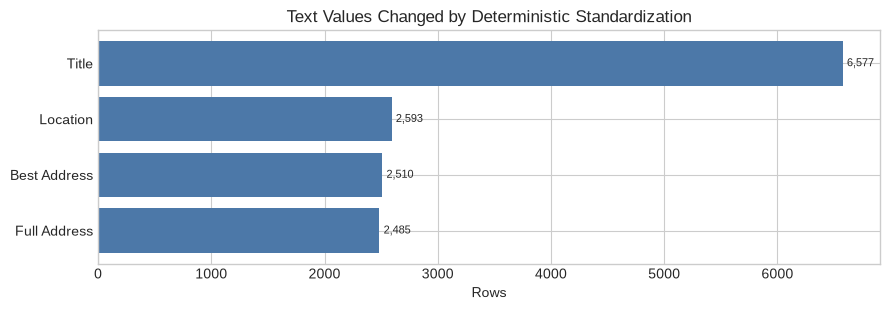

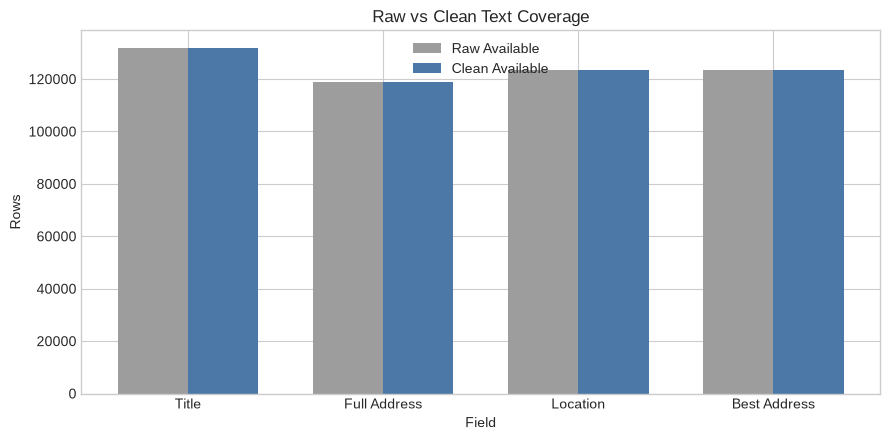

### Before → After Examples

,Field,Raw Text,Clean Text
0,Title,🏡Phòng Trọ Giá Rẻ 30m2 - Full Nội Thất + Ban Công - Ngay KCN Tân Bình,Phòng Trọ Giá Rẻ 30m2 - Full Nội Thất + Ban Công - Ngay KCN Tân Bình
1,Title,🏡 PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - Ban Công - KCN Tân Bình,PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - Ban Công - KCN Tân Bình
2,Title,🏡Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Công - Công Viên Phần Mềm,Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Công - Công Viên Phần Mềm
3,Title,🏡 Phòng Trọ Giá Rẻ - Full Nội Thất & Ban Công - Ngay Cầu Tham Lương,Phòng Trọ Giá Rẻ - Full Nội Thất & Ban Công - Ngay Cầu Tham Lương
4,Title,🏡 Phòng Mới Cao Cấp 30m2 - Full Nội Thất + Máy Giặt - Gác Cao - Tô Ký,Phòng Mới Cao Cấp 30m2 - Full Nội Thất + Máy Giặt - Gác Cao - Tô Ký
5,Full Address,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ...","23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ..."
6,Full Address,"25/16/1, , Tăng Nhơn Phú TP. Hồ Chí Minh","25/16/1, Tăng Nhơn Phú TP. Hồ Chí Minh"
7,Full Address,"17/6N, Đường số 22, , Hiệp Bình TP. Hồ Chí Minh","17/6N, Đường số 22, Hiệp Bình TP. Hồ Chí Minh"
8,Full Address,"Nguyễn Tri Phương, , Vườn Lài TP. Hồ Chí Minh","Nguyễn Tri Phương, Vườn Lài TP. Hồ Chí Minh"
9,Full Address,"380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh ⚜️NỘI THẤT TRANG BỊ ĐẦY ĐỦ⚜️ ✏ Máy đ...","380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh NỘI THẤT TRANG BỊ ĐẦY ĐỦ Máy điều hò..."


**Remaining Issues:** cleanup standardizes representation only; it does not infer missing text.

In [4]:
silver_df=build_silver_dataset(bronze_df, raw_evidence)
TEXT_FIELDS={'Title':('title_raw','title_clean'),'Full Address':('full_address_text','full_address_text_clean'),'Location':('location_raw','location_raw_clean'),'Best Address':('best_address_text','best_address_text_clean')}
text_summary=text_change_summary(bronze_df,silver_df,TEXT_FIELDS)
display(text_summary)
barh_table(text_summary,'Field','Changed Rows','Text Values Changed by Deterministic Standardization')
grouped_coverage(text_summary,'Raw vs Clean Text Coverage')
display(Markdown('### Before → After Examples'))
display(changed_text_examples(bronze_df,silver_df,TEXT_FIELDS,20))
display(Markdown('**Remaining Issues:** cleanup standardizes representation only; it does not infer missing text.'))


## 04. Title Quality Processing

> **Purpose:** Identify titles that are usable for downstream inspection.

### Actual Rule
`MISSING` when `title_clean` is null; `TOO_SHORT` when non-null length is below 5 characters; otherwise `USABLE`.

### Input → Output
`title_raw` → `title_clean` → `title_quality_status`


,Status,Actual Rule,Meaning,Downstream Implication
0,USABLE,title_clean is present and length ≥ 5,Text is structurally usable,Eligible subject to other fields
1,TOO_SHORT,title_clean length < 5,Insufficient title evidence,Requires review
2,MISSING,title_clean is NULL,No usable title,Requires review


,Status,Rows,Percentage (%)
0,USABLE,131297,99.14
1,TOO_SHORT,650,0.49
2,MISSING,489,0.37


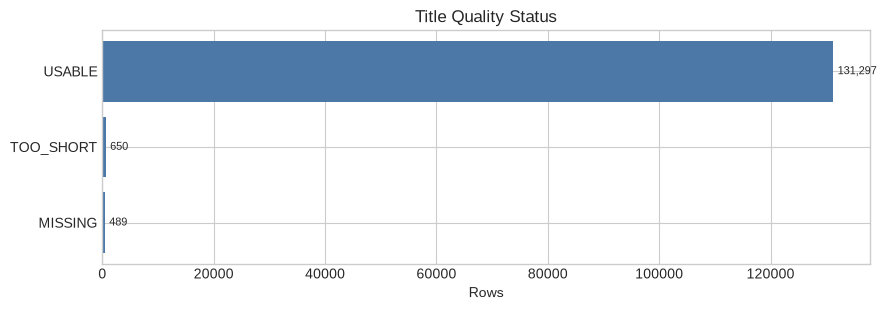

,Example Status,rental_post_id,source_code,title_raw,title_clean,title_quality_status
0,TOO_SHORT,55121,nhatrovn,101,101,TOO_SHORT
1,TOO_SHORT,55124,nhatrovn,103,103,TOO_SHORT
2,TOO_SHORT,55127,nhatrovn,101,101,TOO_SHORT
3,TOO_SHORT,55130,nhatrovn,301,301,TOO_SHORT
4,TOO_SHORT,55133,nhatrovn,102,102,TOO_SHORT
5,MISSING,54295,nhatot,NaN,None,MISSING
6,MISSING,54306,nhatot,NaN,None,MISSING
7,MISSING,54312,nhatot,NaN,None,MISSING
8,MISSING,54320,nhatot,NaN,None,MISSING
9,MISSING,54323,nhatot,NaN,None,MISSING


In [5]:
title_definitions=pd.DataFrame([
 ['USABLE','title_clean is present and length ≥ 5','Text is structurally usable','Eligible subject to other fields'],
 ['TOO_SHORT','title_clean length < 5','Insufficient title evidence','Requires review'],
 ['MISSING','title_clean is NULL','No usable title','Requires review'],
],columns=['Status','Actual Rule','Meaning','Downstream Implication'])
title_status=status_summary(silver_df.title_quality_status,'Status')
display(title_definitions); display(title_status)
barh_table(title_status,'Status','Rows','Title Quality Status')
display(sample_status_rows(silver_df,'title_quality_status',['TOO_SHORT','MISSING'],['rental_post_id','source_code','title_raw','title_clean','title_quality_status'],5))


## 05. Address Standardization & Parsing

> **Purpose:** Standardize the best available address and expose parser evidence without guessing.

### Actual Rule and Input → Output
```text
best_address_text → best_address_text_clean → Address Parser
  ├─ street_text_extracted
  ├─ ward_text_extracted
  ├─ district_text_extracted
  ├─ province_text_extracted
  └─ parse_status
```
Parser statuses reflect actual extracted components and recognition evidence.


,Field,Total Rows,Raw Available,Clean Available,Changed Rows,Unchanged Rows,Changed (%),Cleaned to NULL,Recovered
0,Best Address,132436,123494,123494,2510,129926,1.9,0,0


,Field,Raw Text,Clean Text
0,Best Address,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ...","23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ..."
1,Best Address,"25/16/1, , Tăng Nhơn Phú TP. Hồ Chí Minh","25/16/1, Tăng Nhơn Phú TP. Hồ Chí Minh"
2,Best Address,"17/6N, Đường số 22, , Hiệp Bình TP. Hồ Chí Minh","17/6N, Đường số 22, Hiệp Bình TP. Hồ Chí Minh"
3,Best Address,"Nguyễn Tri Phương, , Vườn Lài TP. Hồ Chí Minh","Nguyễn Tri Phương, Vườn Lài TP. Hồ Chí Minh"
4,Best Address,"380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh ⚜️NỘI THẤT TRANG BỊ ĐẦY ĐỦ⚜️ ✏ Máy đ...","380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh NỘI THẤT TRANG BỊ ĐẦY ĐỦ Máy điều hò..."
5,Best Address,"117/97, Nguyễn Hữu Cảnh, , Thạnh Mỹ Tây TP. Hồ Chí Minh","117/97, Nguyễn Hữu Cảnh, Thạnh Mỹ Tây TP. Hồ Chí Minh"
6,Best Address,"Trung tâm quận Bình Thạnh số nhà 549 Đường Xô Viết Nghệ Tĩnh, Phường 26 Quận Bình Thạn...","Trung tâm quận Bình Thạnh số nhà 549 Đường Xô Viết Nghệ Tĩnh, Phường 26 Quận Bình Thạn..."
7,Best Address,"Nguyễn Trãi, , Cầu Ông Lãnh TP. Hồ Chí Minh","Nguyễn Trãi, Cầu Ông Lãnh TP. Hồ Chí Minh"
8,Best Address,"223, Bà Hạt, , Vườn Lài TP. Hồ Chí Minh","223, Bà Hạt, Vườn Lài TP. Hồ Chí Minh"
9,Best Address,"60-62, Trần Văn Kỷ, , Bình Thạnh TP. Hồ Chí Minh","60-62, Trần Văn Kỷ, Bình Thạnh TP. Hồ Chí Minh"


,Parsed Field,Available Rows,Missing Rows,Coverage (%)
0,Street,95435,37001,72.06
1,Ward,115790,16646,87.43
2,District,50924,81512,38.45
3,Province,12659,119777,9.56


,Status,Rows,Percentage (%)
0,PARTIALLY_PARSED,75038,56.66
1,PARSED,45791,34.58
2,NO_ADDRESS_EVIDENCE,8942,6.75
3,UNRECOGNIZED_FORMAT,2665,2.01


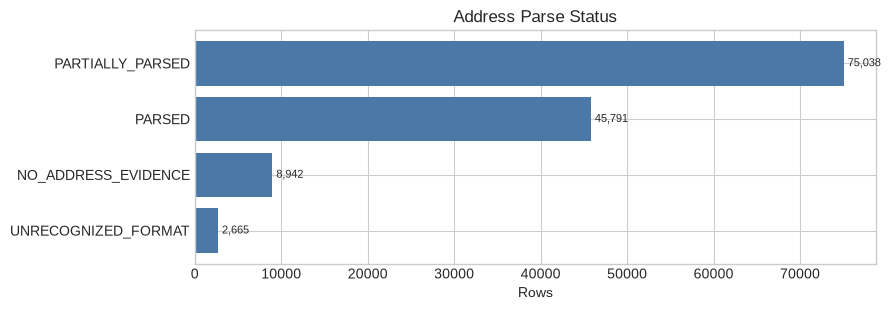

### Before → After Examples

,Example Status,best_address_text,best_address_text_clean,street_text_extracted,ward_text_extracted,district_text_extracted,province_text_extracted,parse_status
0,PARSED,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), Quận 3, TPHCM","Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), Quận 3, TPHCM",NaN,Xã Bình Hưng,Quận 8,TPHCM,PARSED
1,PARSED,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM","Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",NaN,Phường Tân Sơn Hòa,Quận 3,TPHCM,PARSED
2,PARSED,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM","Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",NaN,Phường Tân Sơn Hòa,Quận Bình Thạnh,TPHCM,PARSED
3,PARSED,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM","Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",NaN,Phường Tân Bình,Quận Tân Bình,TPHCM,PARSED
4,PARTIALLY_PARSED,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ...","23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ...",NaN,Phường Chợ Lớn,Quận 5,NaN,PARTIALLY_PARSED
5,PARTIALLY_PARSED,"64/4 Đường số 1, Phường Hiệp Bình Phước, Thủ Đức, Hồ Chí Minh","64/4 Đường số 1, Phường Hiệp Bình Phước, Thủ Đức, Hồ Chí Minh",Đường số 1,Phường Hiệp Bình,NaN,NaN,PARTIALLY_PARSED
6,PARTIALLY_PARSED,"Đường Phan Huy Ích, Phường 15, Tân Bình, Hồ Chí Minh","Đường Phan Huy Ích, Phường 15, Tân Bình, Hồ Chí Minh",Đường Phan Huy Ích,Phường Tân Bình,NaN,NaN,PARTIALLY_PARSED
7,PARTIALLY_PARSED,"Đường Nguyễn Thái Sơn, Phường 5, Gò Vấp, Hồ Chí Minh","Đường Nguyễn Thái Sơn, Phường 5, Gò Vấp, Hồ Chí Minh",Đường Nguyễn Thái Sơn,Phường Tân Sơn Nhất,NaN,NaN,PARTIALLY_PARSED
8,UNRECOGNIZED_FORMAT,"Nguyễn Tri Phương, , Vườn Lài TP. Hồ Chí Minh","Nguyễn Tri Phương, Vườn Lài TP. Hồ Chí Minh",NaN,NaN,NaN,NaN,UNRECOGNIZED_FORMAT
9,UNRECOGNIZED_FORMAT,"223, Bà Hạt, , Vườn Lài TP. Hồ Chí Minh","223, Bà Hạt, Vườn Lài TP. Hồ Chí Minh",NaN,NaN,NaN,NaN,UNRECOGNIZED_FORMAT


**Remaining Issues:** parser statuses describe observed evidence; they do not certify an official address.

In [6]:
address_summary=text_change_summary(bronze_df,silver_df,{'Best Address':('best_address_text','best_address_text_clean')})
display(address_summary); display(changed_text_examples(bronze_df,silver_df,{'Best Address':('best_address_text','best_address_text_clean')},12))
components={'Street':'street_text_extracted','Ward':'ward_text_extracted','District':'district_text_extracted','Province':'province_text_extracted'}
address_coverage=pd.DataFrame([{'Parsed Field':label,'Available Rows':int(silver_df[col].notna().sum()),'Missing Rows':int(silver_df[col].isna().sum()),'Coverage (%)':round(silver_df[col].notna().mean()*100,2)} for label,col in components.items()])
parse_status=status_summary(silver_df.parse_status,'Status')
display(address_coverage); display(parse_status)
barh_table(parse_status,'Status','Rows','Address Parse Status')
address_examples=sample_status_rows(silver_df,'parse_status',['PARSED','PARTIALLY_PARSED','UNRECOGNIZED_FORMAT','NO_ADDRESS_EVIDENCE'],['best_address_text','best_address_text_clean','street_text_extracted','ward_text_extracted','district_text_extracted','province_text_extracted','parse_status'],4)
display(Markdown('### Before → After Examples')); display(address_examples)
display(Markdown('**Remaining Issues:** parser statuses describe observed evidence; they do not certify an official address.'))


## 06. Administrative Unit Mapping

> **Purpose:** Resolve extracted ward text through the existing internal RoomBeacon reference.

### Actual Rule and Input → Output
```text
ward_text_extracted → ward_normalized → internal reference → ward_current → ward_mapping_status
```
Ambiguous candidates remain unresolved; the helper never forces `ward_current`.


,Mapping Status,Rows,Percentage (%)
0,UNCHANGED,101829,76.89
1,MISSING,16646,12.57
2,MAPPED,9011,6.80
3,UNMAPPED,4544,3.43
4,AMBIGUOUS,406,0.31


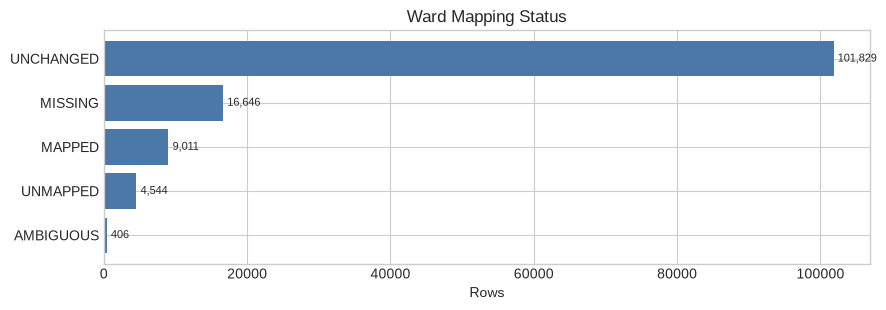

### Before → After Examples

,Example Status,best_address_text,ward_text_extracted,district_text_extracted,ward_normalized,ward_current,ward_mapping_status
0,MAPPED,"Đường Trần Văn Khánh, Phường Tân Thuận Đông, Quận 7, Hồ Chí Minh",Phường Tân Thuận Đông,Quận 7,Phường Tân Thuận Đông,Phường Tân Thuận,MAPPED
1,MAPPED,"Nguyễn Văn Linh, Phường Bình Thuận, Quận 7, TPHCM",Phường Bình Thuận,Quận 7,Phường Bình Thuận,Phường Tân Thuận,MAPPED
2,MAPPED,"Huỳnh Tấn Phát, Phường Bình Thuận, Quận 7, TPHCM",Phường Bình Thuận,Quận 7,Phường Bình Thuận,Phường Tân Thuận,MAPPED
3,MAPPED,"Huỳnh Tấn Phát, Phường Bình Thuận, Quận 7, TPHCM",Phường Bình Thuận,Quận 7,Phường Bình Thuận,Phường Tân Thuận,MAPPED
4,MAPPED,"Đường số 1, Phường Tân Thuận Đông, Quận 7, Hồ Chí Minh",Phường Tân Thuận Đông,Quận 7,Phường Tân Thuận Đông,Phường Tân Thuận,MAPPED
5,AMBIGUOUS,"Mặt tiền Đường Số 1, Phường Phú Mỹ, Quận 7, Thành phố Hồ Chí Minh",Phường Phú Mỹ,Quận 7,Phường Phú Mỹ,NaN,AMBIGUOUS
6,AMBIGUOUS,"PHẠM HỮU LẦU, Phường Phú Mỹ, Quận 7, Thành phố Hồ Chí Minh",Phường Phú Mỹ,Quận 7,Phường Phú Mỹ,NaN,AMBIGUOUS
7,AMBIGUOUS,"115/x/x Phạm Hữu Lầu, Phường Phú Mỹ, Quận 7, Thành phố Hồ Chí Minh",Phường Phú Mỹ,Quận 7,Phường Phú Mỹ,NaN,AMBIGUOUS
8,AMBIGUOUS,"59/xx Chuyên Dùng Chính, Phường Phú Mỹ, Quận 7, Thành phố Hồ Chí Minh",Phường Phú Mỹ,Quận 7,Phường Phú Mỹ,NaN,AMBIGUOUS
9,AMBIGUOUS,"1645/x Huỳnh Tấn Phát, Phường Phú Mỹ, Quận 7, Thành phố Hồ Chí Minh",Phường Phú Mỹ,Quận 7,Phường Phú Mỹ,NaN,AMBIGUOUS


**Remaining Issues:** `ward_current` is an internal reference result, not independently verified administrative truth.

In [7]:
ward_status=status_summary(silver_df.ward_mapping_status,'Mapping Status'); display(ward_status)
barh_table(ward_status,'Mapping Status','Rows','Ward Mapping Status')
ward_examples=sample_status_rows(silver_df,'ward_mapping_status',['MAPPED','AMBIGUOUS','UNMAPPED'],['best_address_text','ward_text_extracted','district_text_extracted','ward_normalized','ward_current','ward_mapping_status'],5)
display(Markdown('### Before → After Examples')); display(ward_examples)
display(Markdown('**Remaining Issues:** `ward_current` is an internal reference result, not independently verified administrative truth.'))


## 07. Price Validation and Parser Comparison Hardening

> **Purpose:** Accept only lineage-aligned existing values or narrowly safe deterministic recovery, while keeping parser disagreement explicit in canonical Silver.

### Actual Rule and Input → Output
```text
Raw Price Evidence → Existing Numeric Price → Reparsed Price → comparison
→ Final Clean Price → price_quality_status + price_parser_comparison_status
```
`MATCH`, `DISAGREEMENT`, `REPARSED_ONLY`, `EXISTING_ONLY`, `NO_PRICE_EVIDENCE`, and `UNCOMPARABLE` describe only available comparison evidence. A disagreement does not select a winner: the existing canonical acceptance rule still controls `price_amount_clean`.


,Status,Actual Rule,Clean Value Behavior
0,VALIDATED_EXISTING,Existing value accepted; lineage and VND/month unit contract pass,Clean value keeps existing numeric value
1,REPARSE_ACCEPTED_CLEAN,Existing value is null; aligned raw syntax reparses and passes domain/unit gates,Clean value receives reparsed value
2,MISSING_OR_REVIEW,No accepted existing or recovery path,Clean value remains null
3,UNKNOWN_LINEAGE,Raw evidence is not aligned to the contributing version,Clean value remains null


,Price Parser Comparison Status,Actual Rule
0,MATCH,Existing and reparsed values are both available and equal
1,DISAGREEMENT,Both values are available and differ; clean value is not silently replaced
2,REPARSED_ONLY,Only reparsed numeric evidence is available
3,EXISTING_ONLY,Only existing numeric evidence is available
4,NO_PRICE_EVIDENCE,Neither numeric value nor non-empty raw evidence is available
5,UNCOMPARABLE,Raw evidence exists but neither comparable numeric value is available


,Status,Rows,Percentage (%)
0,VALIDATED_EXISTING,128048,96.69
1,MISSING_OR_REVIEW,4385,3.31
2,REPARSE_ACCEPTED_CLEAN,3,0.00


,Price Parser Comparison Status,Rows,Percentage (%)
0,MATCH,118635,89.58
1,DISAGREEMENT,9513,7.18
2,UNCOMPARABLE,4225,3.19
3,REPARSED_ONLY,63,0.05


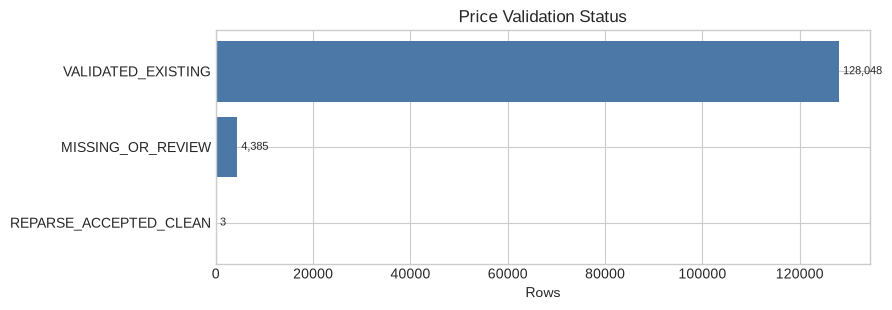

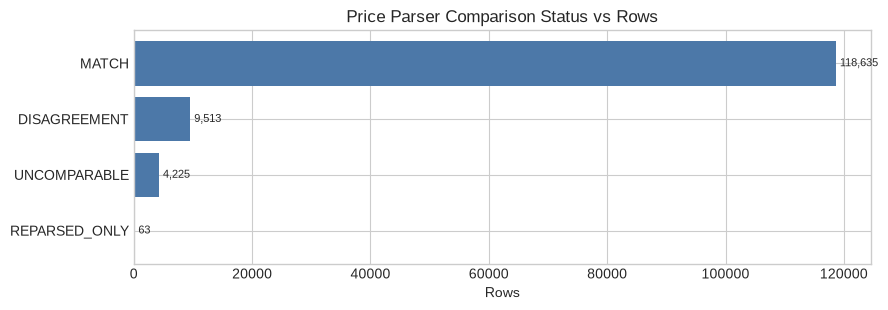

,Metric,Rows,Percentage (%)
0,Total Rows,132436,100.00
1,Raw Price Available,132436,100.00
2,Existing Numeric Available,128148,96.76
3,Reparse Available,128211,96.81
4,Reparse Accepted,3,0.00
5,Parser Agreement,118635,89.58
6,Parser Disagreement,9513,7.18
7,Missing / No Raw,0,0.00
8,Negotiable,182,0.14
9,Parse Failed / Reparse NULL,0,0.00


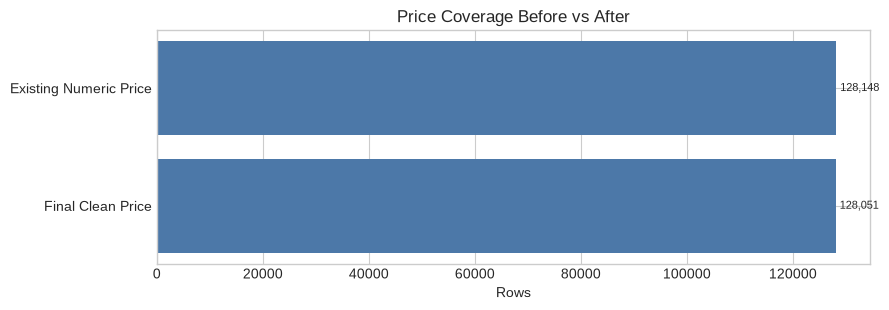

### Parser Disagreement Examples and Final Clean-value Behavior

,source_code,rental_post_id,raw price evidence,existing numeric price,reparsed price,price_amount_clean,price_validation_status,price_parser_comparison_status
0,mogi,53598,3 triệu 100 nghìn,3000000.00,3100000.00,3000000.0,VALIDATED_EXISTING,DISAGREEMENT
1,mogi,53599,3 triệu 300 nghìn,3000000.00,3300000.00,3000000.0,VALIDATED_EXISTING,DISAGREEMENT
3,mogi,53601,3 triệu 800 nghìn,3000000.00,3800000.00,3000000.0,VALIDATED_EXISTING,DISAGREEMENT
4,mogi,53602,3 triệu 700 nghìn,3000000.00,3700000.00,3000000.0,VALIDATED_EXISTING,DISAGREEMENT
5,mogi,53603,3 triệu 300 nghìn,3000000.00,3300000.00,3000000.0,VALIDATED_EXISTING,DISAGREEMENT
6,mogi,53604,3 triệu 500 nghìn,3000000.00,3500000.00,3000000.0,VALIDATED_EXISTING,DISAGREEMENT
10,mogi,53608,4 triệu 400 nghìn,4000000.00,4400000.00,4000000.0,VALIDATED_EXISTING,DISAGREEMENT
27,mogi,53625,1 triệu 500 nghìn,1000000.00,1500000.00,1000000.0,VALIDATED_EXISTING,DISAGREEMENT
28,mogi,53626,1 triệu 500 nghìn,1000000.00,1500000.00,1000000.0,VALIDATED_EXISTING,DISAGREEMENT
30,mogi,53628,1 triệu 600 nghìn,1000000.00,1600000.00,1000000.0,VALIDATED_EXISTING,DISAGREEMENT


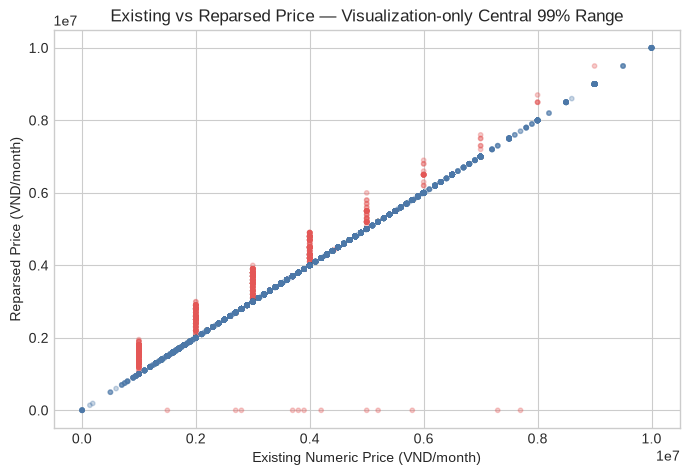

In [8]:
price_audit=numeric_audit_report(bronze_df,raw_evidence,silver_df,'price')
price_defs=pd.DataFrame([
 ['VALIDATED_EXISTING','Existing value accepted; lineage and VND/month unit contract pass','Clean value keeps existing numeric value'],
 ['REPARSE_ACCEPTED_CLEAN','Existing value is null; aligned raw syntax reparses and passes domain/unit gates','Clean value receives reparsed value'],
 ['MISSING_OR_REVIEW','No accepted existing or recovery path','Clean value remains null'],
 ['UNKNOWN_LINEAGE','Raw evidence is not aligned to the contributing version','Clean value remains null'],
],columns=['Status','Actual Rule','Clean Value Behavior'])
comparison_defs=pd.DataFrame([
 ['MATCH','Existing and reparsed values are both available and equal'],['DISAGREEMENT','Both values are available and differ; clean value is not silently replaced'],['REPARSED_ONLY','Only reparsed numeric evidence is available'],['EXISTING_ONLY','Only existing numeric evidence is available'],['NO_PRICE_EVIDENCE','Neither numeric value nor non-empty raw evidence is available'],['UNCOMPARABLE','Raw evidence exists but neither comparable numeric value is available']],columns=['Price Parser Comparison Status','Actual Rule'])
display(price_defs); display(comparison_defs)
price_status=status_summary(silver_df.price_quality_status,'Status'); comparison_status=status_summary(silver_df.price_parser_comparison_status,'Price Parser Comparison Status')
display(price_status); display(comparison_status)
barh_table(price_status,'Status','Rows','Price Validation Status')
barh_table(comparison_status,'Price Parser Comparison Status','Rows','Price Parser Comparison Status vs Rows')
price_metrics=pd.DataFrame({'Metric':['Total Rows','Raw Price Available','Existing Numeric Available','Reparse Available','Reparse Accepted','Parser Agreement','Parser Disagreement','Missing / No Raw','Negotiable','Parse Failed / Reparse NULL','Requires Review / Unavailable'], 'Rows':[len(price_audit),price_audit.raw.notna().sum(),price_audit.existing.notna().sum(),price_audit.reparsed.notna().sum(),price_audit.action.eq('REPARSE_ACCEPTED_CLEAN').sum(),silver_df.price_parser_comparison_status.eq('MATCH').sum(),silver_df.price_parser_comparison_status.eq('DISAGREEMENT').sum(),silver_df.price_parser_comparison_status.eq('NO_PRICE_EVIDENCE').sum(),price_audit.semantic.eq('NEGOTIABLE_NON_NUMERIC').sum(),price_audit.regression.eq('REPARSE_NULL').sum(),silver_df.price_quality_status.isin(['MISSING_OR_REVIEW','UNKNOWN_LINEAGE']).sum()]})
price_metrics['Percentage (%)']=(price_metrics.Rows/len(price_audit)*100).round(2); display(price_metrics)
price_cov=pd.DataFrame({'Stage':['Existing Numeric Price','Final Clean Price'],'Rows':[price_audit.existing.notna().sum(),silver_df.price_amount_clean.notna().sum()]}); barh_table(price_cov,'Stage','Rows','Price Coverage Before vs After')
price_examples=price_audit.assign(source_code=bronze_df.source_code,rental_post_id=bronze_df.rental_post_id,price_amount_clean=silver_df.price_amount_clean,price_validation_status=silver_df.price_quality_status,price_parser_comparison_status=silver_df.price_parser_comparison_status)
disagreement_examples=price_examples.loc[price_examples.price_parser_comparison_status.eq('DISAGREEMENT'),['source_code','rental_post_id','raw','existing','reparsed','price_amount_clean','price_validation_status','price_parser_comparison_status']].head(15).rename(columns={'raw':'raw price evidence','existing':'existing numeric price','reparsed':'reparsed price'})
display(Markdown('### Parser Disagreement Examples and Final Clean-value Behavior')); display(disagreement_examples)
comparable=price_examples.loc[price_examples.existing.notna()&price_examples.reparsed.notna()].copy(); focus=comparable.loc[pd.to_numeric(comparable.existing).le(pd.to_numeric(comparable.existing).quantile(.99)) & pd.to_numeric(comparable.reparsed).le(pd.to_numeric(comparable.reparsed).quantile(.99))].head(8000)
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(pd.to_numeric(focus.existing),pd.to_numeric(focus.reparsed),s=10,alpha=.3,c=np.where(focus.price_parser_comparison_status.eq('DISAGREEMENT'),REVIEW,COLOR)); ax.set(title='Existing vs Reparsed Price — Visualization-only Central 99% Range',xlabel='Existing Numeric Price (VND/month)',ylabel='Reparsed Price (VND/month)'); plt.tight_layout(); plt.show()


## 08. Area Validation

> **Purpose:** Apply the same lineage-safe validation pattern to area evidence.

### Actual Rule and Input → Output
`Raw Area Evidence → Existing Area → Reparsed Area → Final Clean Area → Area Status`. Existing positive values are retained only with aligned lineage; recovery requires safe full-string area syntax and a positive parsed value.


,Status,Actual Rule,Clean Value Behavior
0,VALIDATED_EXISTING,Positive existing area with aligned lineage,Keep existing value
1,REPARSE_ACCEPTED_CLEAN,Null existing area; aligned safe syntax reparses positive,Use reparsed value
2,MISSING_OR_REVIEW,No accepted existing or recovery path,Remain null
3,UNKNOWN_LINEAGE,Evidence alignment cannot be established,Remain null


,Status,Rows,Percentage (%)
0,VALIDATED_EXISTING,130316,98.40
1,MISSING_OR_REVIEW,2107,1.59
2,REPARSE_ACCEPTED_CLEAN,13,0.01


,Metric,Rows,Percentage (%)
0,Total Rows,132436,100.00
1,Raw Area Available,130375,98.44
2,Existing Area Available,130316,98.40
3,Reparsed Area,130372,98.44
4,Accepted Reparse,13,0.01
5,Parser Agreement,130316,98.40
6,Parser Disagreement,0,0.00
7,Missing / Review,2107,1.59


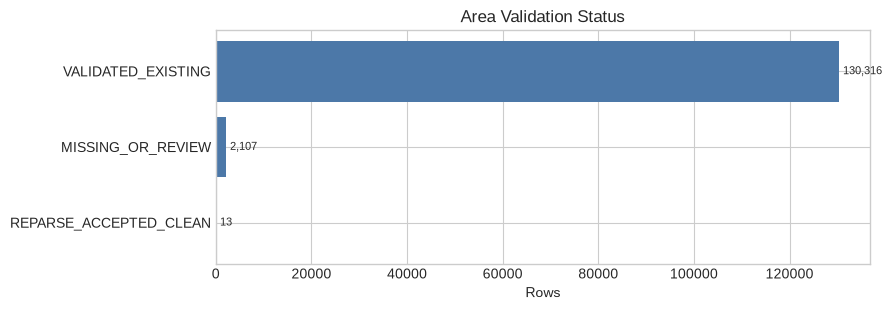

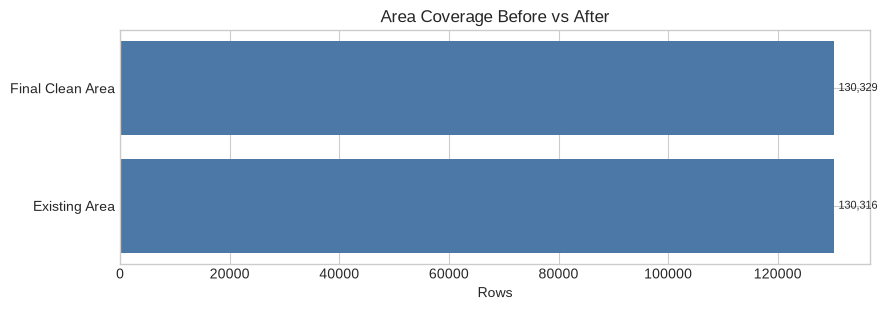

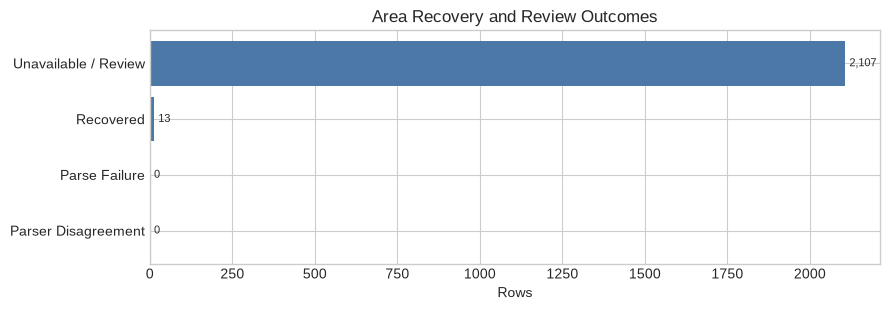

,Example Category,source_code,rental_post_id,raw,existing,reparsed,final_clean,quality_status
0,Validated Existing,mogi,53598,16 m 2 0 PN 0 WC,16.00,16.00,16.0,VALIDATED_EXISTING
1,Validated Existing,mogi,53599,17 m 2 0 PN 0 WC,17.00,17.00,17.0,VALIDATED_EXISTING
2,Validated Existing,mogi,53600,30 m 2 0 PN 0 WC,30.00,30.00,30.0,VALIDATED_EXISTING
41,Missing / Review,chothuenha,53639,NaN,None,None,NaN,MISSING_OR_REVIEW
55,Missing / Review,chothuenha,53653,NaN,None,None,NaN,MISSING_OR_REVIEW
67,Missing / Review,chothuenha,53665,NaN,None,None,NaN,MISSING_OR_REVIEW
14864,Accepted Reparse,chothuephongtro,74040,1000000 m 2,None,1000000.00,1000000.0,REPARSE_ACCEPTED_CLEAN
63271,Accepted Reparse,chothuephongtro,159098,6000000 m 2,None,6000000.00,6000000.0,REPARSE_ACCEPTED_CLEAN
81303,Accepted Reparse,chothuephongtro,189871,6500000 m 2,None,6500000.00,6500000.0,REPARSE_ACCEPTED_CLEAN


In [9]:
area_audit=numeric_audit_report(bronze_df,raw_evidence,silver_df,'area')
area_defs=pd.DataFrame([
 ['VALIDATED_EXISTING','Positive existing area with aligned lineage','Keep existing value'],['REPARSE_ACCEPTED_CLEAN','Null existing area; aligned safe syntax reparses positive','Use reparsed value'],['MISSING_OR_REVIEW','No accepted existing or recovery path','Remain null'],['UNKNOWN_LINEAGE','Evidence alignment cannot be established','Remain null']],columns=['Status','Actual Rule','Clean Value Behavior'])
display(area_defs)
area_status=status_summary(silver_df.area_quality_status,'Status'); display(area_status)
area_metrics=pd.DataFrame({'Metric':['Total Rows','Raw Area Available','Existing Area Available','Reparsed Area','Accepted Reparse','Parser Agreement','Parser Disagreement','Missing / Review'],'Rows':[len(area_audit),area_audit.raw.notna().sum(),area_audit.existing.notna().sum(),area_audit.reparsed.notna().sum(),area_audit.action.eq('REPARSE_ACCEPTED_CLEAN').sum(),area_audit.regression.eq('CANONICAL_MATCH').sum(),area_audit.regression.eq('DIFFERENT_REVIEW').sum(),silver_df.area_quality_status.isin(['MISSING_OR_REVIEW','UNKNOWN_LINEAGE']).sum()]}); area_metrics['Percentage (%)']=(area_metrics.Rows/len(area_audit)*100).round(2); display(area_metrics)
barh_table(area_status,'Status','Rows','Area Validation Status')
area_cov=pd.DataFrame({'Stage':['Existing Area','Final Clean Area'],'Rows':[area_audit.existing.notna().sum(),silver_df.area_value_clean.notna().sum()]}); barh_table(area_cov,'Stage','Rows','Area Coverage Before vs After')
area_outcomes=pd.DataFrame({'Outcome':['Recovered','Parser Disagreement','Parse Failure','Unavailable / Review'],'Rows':[area_audit.action.eq('REPARSE_ACCEPTED_CLEAN').sum(),area_audit.regression.eq('DIFFERENT_REVIEW').sum(),area_audit.regression.eq('REPARSE_NULL').sum(),silver_df.area_quality_status.isin(['MISSING_OR_REVIEW','UNKNOWN_LINEAGE']).sum()]}); barh_table(area_outcomes,'Outcome','Rows','Area Recovery and Review Outcomes')
area_examples=area_audit.assign(source_code=bronze_df.source_code,rental_post_id=bronze_df.rental_post_id)
area_examples['Example Category']=np.select([area_examples.action.eq('VALIDATED_EXISTING'),area_examples.action.eq('REPARSE_ACCEPTED_CLEAN'),area_examples.regression.eq('DIFFERENT_REVIEW'),area_examples.regression.eq('REPARSE_NULL')],['Validated Existing','Accepted Reparse','Parser Disagreement','Parse Failure'],default='Missing / Review')
display(area_examples.groupby('Example Category',group_keys=False).head(3)[['Example Category','source_code','rental_post_id','raw','existing','reparsed','final_clean','quality_status']])


## 09. Numeric Outlier Flags

> **Purpose:** Flag statistical tails without deleting or changing any value.

### Actual Rule
For each clean numeric field, activate only with at least four values and positive finite IQR. Flag values below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR`.


,Metric,Threshold Method,Q1,Q3,Lower Threshold,Upper Threshold
0,Price,1.5 × IQR,3000000.0,5000000.0,0.0,8000000.0
1,Area,1.5 × IQR,22.0,35.0,2.5,54.5


,Status,Rows,Percentage (%)
0,NOT_OUTLIER,120229,90.78
1,PRICE_OUTLIER,6902,5.21
2,AREA_OUTLIER,4728,3.57
3,PRICE_AND_AREA_OUTLIER,577,0.44


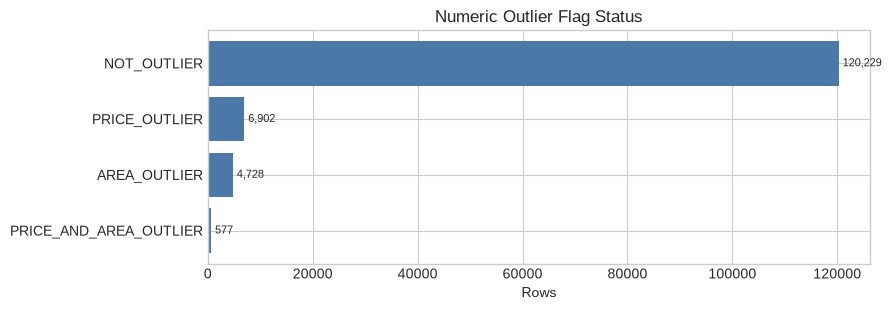

/tmp/ipykernel_57226/515126690.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  fig,ax=plt.subplots(figsize=(9,3.8)); ax.boxplot(price_plot[price_plot.le(price_limit)],vert=False); ax.set(title='Price Distribution — Visualization-only Central 99% Range',xlabel='Clean Price (VND/month)',yticks=[]); plt.tight_layout(); plt.show()


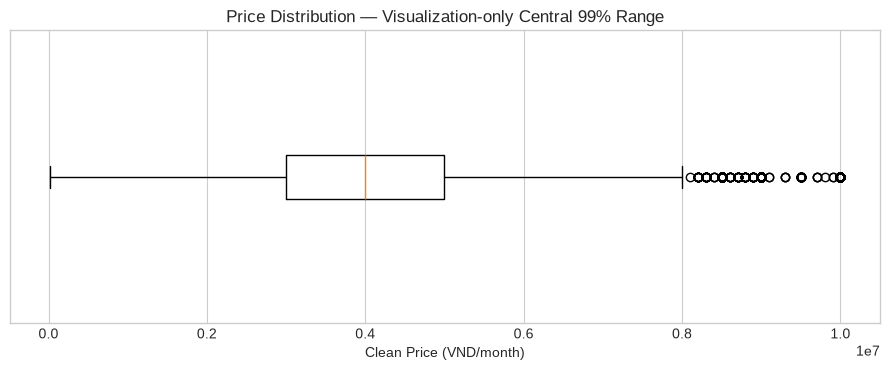

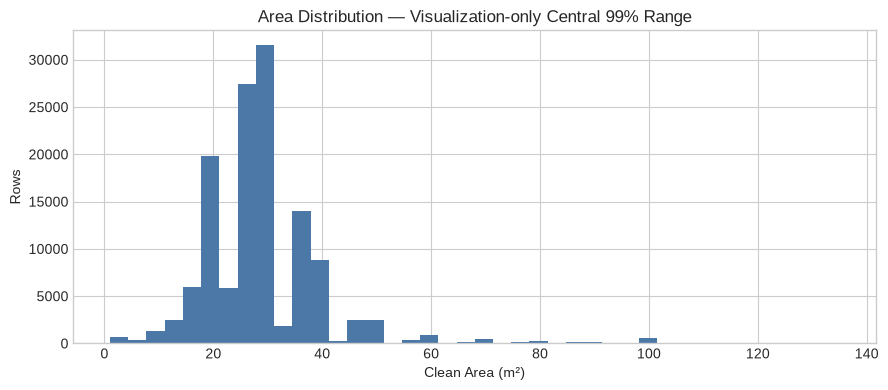

,rental_post_id,source_code,title_raw,price_amount,price_amount_clean,area_value,area_value_clean,best_address_text,numeric_outlier_status
28,53626,mogi,Ktx phòng đẹp Phú Nhuận số lượng có hạn chỉ thừ 1tr5,1000000.0,1000000.0,80.0,80.0,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",AREA_OUTLIER
30,53628,mogi,Phú Nhuận Ký Túc Xá Tư Nhân Bao Trọn Chi Phí Chỉ Từ 1Tr6,1000000.0,1000000.0,120.0,120.0,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",AREA_OUTLIER
32,53630,mogi,"Quận 5, 10, Phú Nhuận Ký Túc Xá chỉ từ 1.000K",1000000.0,1000000.0,80.0,80.0,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",AREA_OUTLIER
34,53632,mogi,"Q.5, Q.10, Phú Nhuận ktx sinh viên chỉ từ 1.300.000 Đ/tháng",1000000.0,1000000.0,120.0,120.0,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",AREA_OUTLIER
35,53633,mogi,KTX hiện đại - tiện nghi trọn gói chỉ từ 1.500.000 đang nhiều ưu đãi,1000000.0,1000000.0,80.0,80.0,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",AREA_OUTLIER
37,53635,mogi,Ký túc xá Phú Nhuận 1tr6 sạch – tự do - thoải mái,1000000.0,1000000.0,120.0,120.0,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",AREA_OUTLIER
38,53636,mogi,Ktx Hiện Đại - Cao Cấp - Thuận Tiện Trung Tâm PN-Q10-Q5,1000000.0,1000000.0,80.0,80.0,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",AREA_OUTLIER
39,53637,mogi,Ktx Cao Cấp Phú Nhuận Bao Trọn Chi Phí 1TR6,1000000.0,1000000.0,120.0,120.0,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",AREA_OUTLIER
40,53638,mogi,"Chỉ từ 1.600.000 Giá Đã Bao Gồm Tất Cả Các Chi Phí, Không Phát Sinh",1000000.0,1000000.0,120.0,120.0,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",AREA_OUTLIER
46,53644,mogi,1PN ban công Ngã tư Phú Nhuận/ Phan xích Long/Nơ Trang Long/Bà Chiểu,10000000.0,10000000.0,30.0,30.0,"Phan Đăng Lưu, Phường 7, Quận Phú Nhuận, TPHCM",PRICE_OUTLIER


**Remaining Issues:** an IQR flag is statistical review evidence, not proof that a listing is wrong. No row is dropped.

In [10]:
outlier_thresholds=pd.concat([iqr_threshold_diagnostics(silver_df.price_amount_clean,'Price'),iqr_threshold_diagnostics(silver_df.area_value_clean,'Area')],ignore_index=True); display(outlier_thresholds)
outlier_status=status_summary(silver_df.numeric_outlier_status,'Status'); display(outlier_status); barh_table(outlier_status,'Status','Rows','Numeric Outlier Flag Status')
price_plot=pd.to_numeric(silver_df.price_amount_clean,errors='coerce').dropna(); price_limit=price_plot.quantile(.99)
fig,ax=plt.subplots(figsize=(9,3.8)); ax.boxplot(price_plot[price_plot.le(price_limit)],vert=False); ax.set(title='Price Distribution — Visualization-only Central 99% Range',xlabel='Clean Price (VND/month)',yticks=[]); plt.tight_layout(); plt.show()
area_plot=pd.to_numeric(silver_df.area_value_clean,errors='coerce').dropna(); area_limit=area_plot.quantile(.99)
fig,ax=plt.subplots(figsize=(9,4)); ax.hist(area_plot[area_plot.le(area_limit)],bins=40,color=COLOR); ax.set(title='Area Distribution — Visualization-only Central 99% Range',xlabel='Clean Area (m²)',ylabel='Rows'); plt.tight_layout(); plt.show()
outlier_examples=silver_df.loc[silver_df.numeric_outlier_status.ne('NOT_OUTLIER'),['rental_post_id','source_code','title_raw','price_amount','price_amount_clean','area_value','area_value_clean','best_address_text','numeric_outlier_status']].head(20); display(outlier_examples)
display(Markdown('**Remaining Issues:** an IQR flag is statistical review evidence, not proof that a listing is wrong. No row is dropped.'))


## 10. Coordinate Trust Classification

> **Purpose:** Distinguish availability, geometric validity, provider trust, and repeated-point conflicts.

### Actual Rule and Input → Output
```text
latitude / longitude → pair available? → finite/in range/non-zero?
→ trusted provider? → repeated coordinate? → address consistency?
→ coordinate_trust_reason → coordinate_quality_status
```
Canonical `INVALID` includes missing, non-finite, out-of-bounds, and zero pairs. The presentation uses the more specific existing `coordinate_trust_reason`; no Silver semantics are changed.


,Coordinate Status,Rows,Percentage (%)
0,MISSING_COORDINATE_PAIR,119587,90.30
1,SHARED_POINT_CONFLICTING_ADDRESSES,10572,7.98
2,TRUSTED_UNIQUE_POINT,1470,1.11
3,TRUSTED_SHARED_ADDRESS,807,0.61


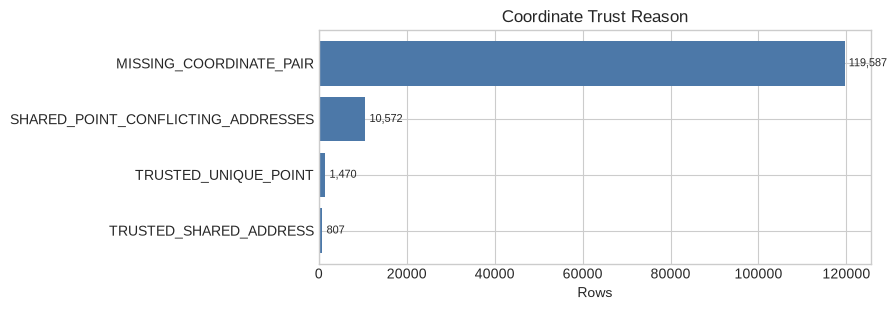

,Metric,Rows
0,Complete Coordinate Pairs,12849
1,Missing Coordinate Pairs,119587
2,Invalid Range / Non-finite / Zero,0
3,Unique Pairs,1470
4,Repeated Pair Records,11379
5,Largest Repeated Group,285
6,Usable,2277
7,Untrusted,10572


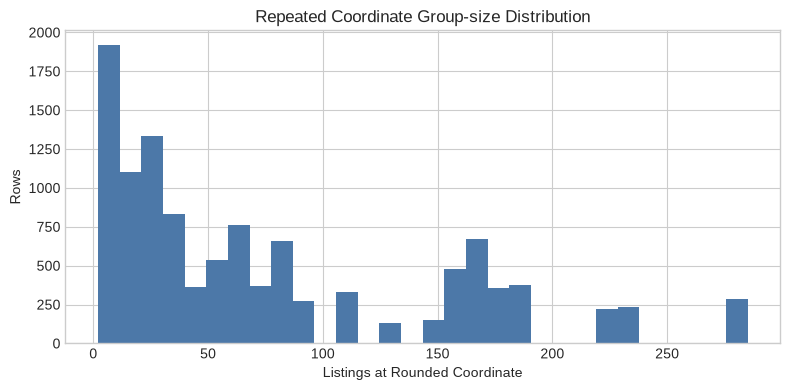

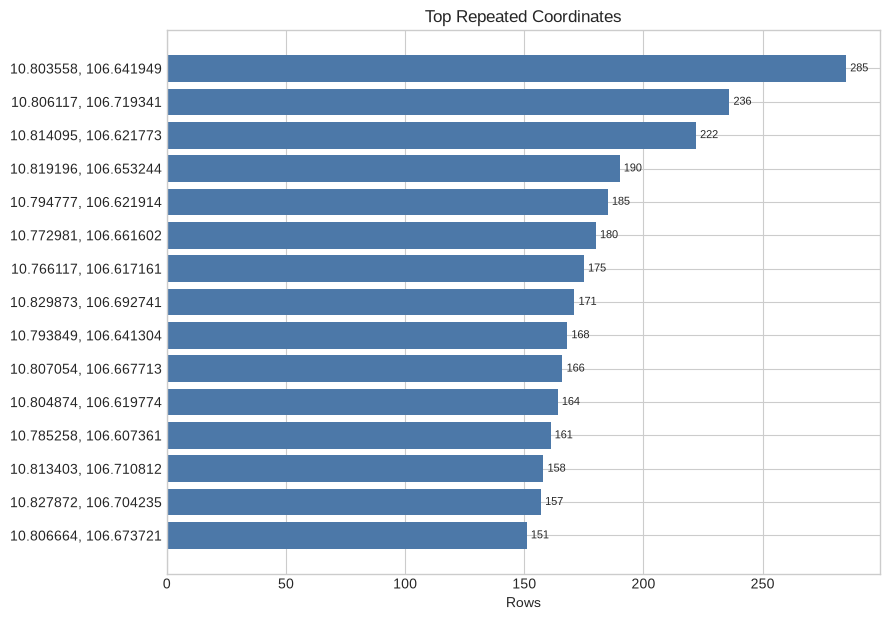

,Latitude,Longitude,Listings,Distinct_Addresses,Distinct_Wards,Distinct_Sources,Coordinate_Status
431,10.803558,106.641949,285,47,4,2,SHARED_POINT_CONFLICTING_ADDRESSES
456,10.806117,106.719341,236,33,2,2,SHARED_POINT_CONFLICTING_ADDRESSES
501,10.814095,106.621773,222,51,3,2,SHARED_POINT_CONFLICTING_ADDRESSES
524,10.819196,106.653244,190,48,3,2,SHARED_POINT_CONFLICTING_ADDRESSES
364,10.794777,106.621914,185,53,3,2,SHARED_POINT_CONFLICTING_ADDRESSES
227,10.772981,106.661602,180,19,3,2,SHARED_POINT_CONFLICTING_ADDRESSES
189,10.766117,106.617161,175,21,4,2,SHARED_POINT_CONFLICTING_ADDRESSES
552,10.829873,106.692741,171,27,3,2,SHARED_POINT_CONFLICTING_ADDRESSES
360,10.793849,106.641304,168,35,3,1,SHARED_POINT_CONFLICTING_ADDRESSES
466,10.807054,106.667713,166,42,5,2,SHARED_POINT_CONFLICTING_ADDRESSES


In [11]:
coordinate_reason=status_summary(silver_df.coordinate_trust_reason,'Coordinate Status'); display(coordinate_reason); barh_table(coordinate_reason,'Coordinate Status','Rows','Coordinate Trust Reason')
coord_metrics=pd.DataFrame({'Metric':['Complete Coordinate Pairs','Missing Coordinate Pairs','Invalid Range / Non-finite / Zero','Unique Pairs','Repeated Pair Records','Largest Repeated Group','Usable','Untrusted'], 'Rows':[(silver_df.map_latitude.notna()&silver_df.map_longitude.notna()).sum(),silver_df.coordinate_trust_reason.eq('MISSING_COORDINATE_PAIR').sum(),silver_df.coordinate_trust_reason.isin(['NONFINITE_COORDINATE','OUT_OF_BOUNDS','ZERO_COORDINATE']).sum(),silver_df.coordinate_pair_listing_count.eq(1).sum(),silver_df.coordinate_pair_listing_count.gt(1).sum(),silver_df.coordinate_pair_listing_count.max(),silver_df.has_trusted_coordinate.sum(),(~silver_df.has_trusted_coordinate & silver_df.coordinate_pair_valid).sum()]}); display(coord_metrics)
repeated=silver_df.loc[silver_df.coordinate_pair_listing_count.gt(1),'coordinate_pair_listing_count']
fig,ax=plt.subplots(figsize=(8,4)); ax.hist(repeated,bins=min(30,max(5,repeated.nunique())),color=COLOR); ax.set(title='Repeated Coordinate Group-size Distribution',xlabel='Listings at Rounded Coordinate',ylabel='Rows'); plt.tight_layout(); plt.show()
coord_groups=(silver_df.loc[silver_df.coordinate_pair_listing_count.gt(1)].assign(Latitude=lambda x:x.map_latitude.round(6),Longitude=lambda x:x.map_longitude.round(6)).groupby(['Latitude','Longitude'],dropna=True).agg(Listings=('rental_post_id','size'),Distinct_Addresses=('full_address_text','nunique'),Distinct_Wards=('ward_current','nunique'),Distinct_Sources=('source_code','nunique'),Coordinate_Status=('coordinate_trust_reason',lambda s:', '.join(sorted(set(s.dropna().astype(str)))))).reset_index().sort_values('Listings',ascending=False))
top_coord=coord_groups.head(15).copy(); top_coord['Coordinate']=top_coord.Latitude.astype(str)+', '+top_coord.Longitude.astype(str)
barh_table(top_coord,'Coordinate','Listings','Top Repeated Coordinates')
display(top_coord[['Latitude','Longitude','Listings','Distinct_Addresses','Distinct_Wards','Distinct_Sources','Coordinate_Status']])


## 11. Cross-field Consistency — Price × Area Hardening

> **Purpose:** Separate data availability from relationship-quality review.

### Actual Rule
`price_area_availability_status` distinguishes `AVAILABLE`, `MISSING_PRICE`, `MISSING_AREA`, and `MISSING_BOTH` using canonical clean fields. For available pairs, `price_area_quality_status` applies existing price/area IQR flags first, then a 1.5×IQR audit of `price_amount_clean / area_value_clean`. `CHECKED_NO_FLAG` means these deterministic checks found no flag—not that the relationship is universally “consistent.” The ratio is an audit metric only and is not persisted.


,Price × Area Availability Status,Rows,Percentage (%)
0,AVAILABLE,125964,95.11
1,MISSING_PRICE,4365,3.30
2,MISSING_AREA,2087,1.58
3,MISSING_BOTH,20,0.02


,Price × Area Quality Status,Rows,Percentage (%)
0,CHECKED_NO_FLAG,111908,84.50
1,PRICE_OUTLIER_REVIEW,6863,5.18
2,INSUFFICIENT_DATA,6472,4.89
3,AREA_OUTLIER_REVIEW,4539,3.43
4,EXTREME_PRICE_PER_AREA_REVIEW,2077,1.57
5,BOTH_OUTLIERS_REVIEW,577,0.44


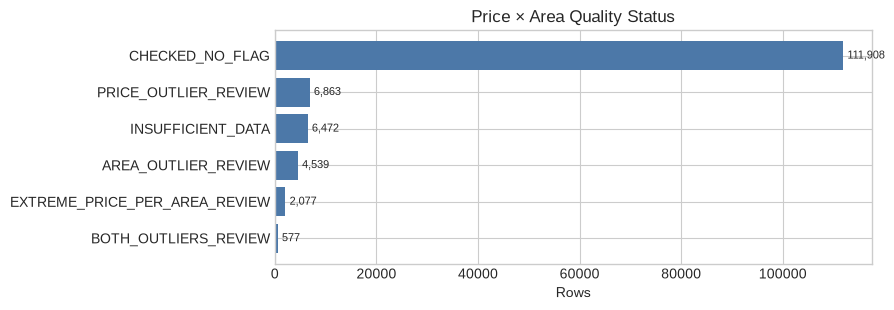

,Metric,Threshold Method,Q1,Q3,Lower Threshold,Upper Threshold
0,Price per Area Audit,1.5 × IQR,113636.363636,192592.592593,-4797.979798,311026.936027


### Representative Non-normal Price × Area States

,title_clean,price_amount_clean,area_value_clean,price_per_area_audit,numeric_outlier_status,price_area_availability_status,price_area_quality_status,best_address_text_clean,source_code
28,Ktx phòng đẹp Phú Nhuận số lượng có hạn chỉ thừ 1tr5,1000000.0,80.0,12500.000000,AREA_OUTLIER,AVAILABLE,AREA_OUTLIER_REVIEW,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",mogi
30,Phú Nhuận Ký Túc Xá Tư Nhân Bao Trọn Chi Phí Chỉ Từ 1Tr6,1000000.0,120.0,8333.333333,AREA_OUTLIER,AVAILABLE,AREA_OUTLIER_REVIEW,"Hồ Văn Huê, Phường 9, Quận Phú Nhuận, TPHCM",mogi
32,"Quận 5, 10, Phú Nhuận Ký Túc Xá chỉ từ 1.000K",1000000.0,80.0,12500.000000,AREA_OUTLIER,AVAILABLE,AREA_OUTLIER_REVIEW,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",mogi
34,"Q.5, Q.10, Phú Nhuận ktx sinh viên chỉ từ 1.300.000 Đ/tháng",1000000.0,120.0,8333.333333,AREA_OUTLIER,AVAILABLE,AREA_OUTLIER_REVIEW,"Nguyễn Tri Phương, Phường 6, Quận 5, TPHCM",mogi
41,"CHO THUÊ PHÒNG TRỌ - Khu vực nhà ở quân đội, an ninh yên tĩnh, chính chủ.",6500000.0,NaN,NaN,NOT_OUTLIER,MISSING_AREA,INSUFFICIENT_DATA,"132 Đường Nguyễn Hữu Cảnh, Phường 22, Quận Bình Thạnh, Hồ Chí Minh",chothuenha
46,1PN ban công Ngã tư Phú Nhuận/ Phan xích Long/Nơ Trang Long/Bà Chiểu,10000000.0,30.0,333333.333333,PRICE_OUTLIER,AVAILABLE,PRICE_OUTLIER_REVIEW,"Phan Đăng Lưu, Phường 7, Quận Phú Nhuận, TPHCM",mogi
55,"Cho thuê phòng trọ 2,5 triệu - Diện tích 16m2 - mới 100% - Có máy lạnh",2500000.0,NaN,NaN,NOT_OUTLIER,MISSING_AREA,INSUFFICIENT_DATA,"80/1 Đường Dương Quảng Hàm, Phường 5, Quận Gò Vấp, Hồ Chí Minh",chothuenha
57,CĂN HỘ STUDIO FULL NỘI THẤT - BAN CÔNG CHILL CĂN HỘ STUDIO FULL NỘI THẤT - BAN CÔNG CHILL,8500000.0,40.0,212500.000000,PRICE_OUTLIER,AVAILABLE,PRICE_OUTLIER_REVIEW,"Đường Nguyễn Đình Chiểu, Phường Đa Kao, Quận 1, Hồ Chí Minh",chothuephongtro
67,Phòng trọ 21m2 (khu Nam Long ngay ngã tư ga),2500000.0,NaN,NaN,NOT_OUTLIER,MISSING_AREA,INSUFFICIENT_DATA,"8C7 khu phố 9 Đường Hà Huy Giáp, Phường An Phú Đông, Quận 12, Hồ Chí Minh",chothuenha
75,CHO THUÊ NHÀ TRỌ – TRUNG TÂM QUẬN 1 - GẦN CHỢ BẾN THÀNH,5000000.0,NaN,NaN,NOT_OUTLIER,MISSING_AREA,INSUFFICIENT_DATA,"Đường Nguyễn Thái Bình, Phường Nguyễn Thái Bình, Quận 1, Hồ Chí Minh",chothuenha


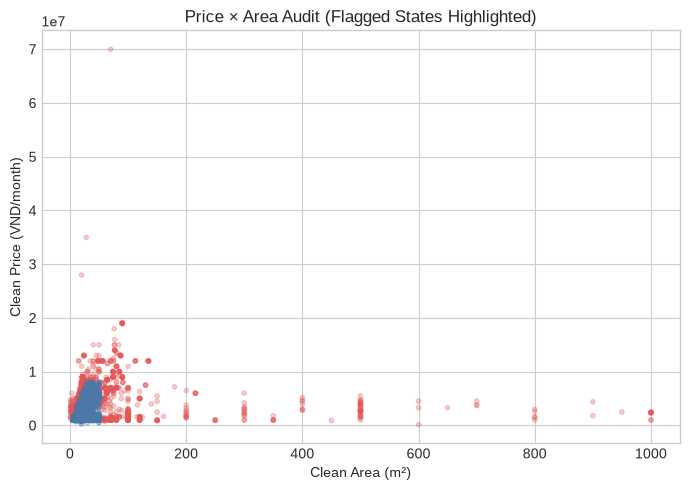

In [12]:
availability_status=status_summary(silver_df.price_area_availability_status,'Price × Area Availability Status')
quality_status=status_summary(silver_df.price_area_quality_status,'Price × Area Quality Status')
display(availability_status); display(quality_status)
barh_table(quality_status,'Price × Area Quality Status','Rows','Price × Area Quality Status')
price_per_area_audit=pd.to_numeric(silver_df.price_amount_clean,errors='coerce')/pd.to_numeric(silver_df.area_value_clean,errors='coerce').where(pd.to_numeric(silver_df.area_value_clean,errors='coerce').gt(0))
ratio_thresholds=iqr_threshold_diagnostics(price_per_area_audit,'Price per Area Audit'); display(ratio_thresholds)
review_examples=silver_df.assign(price_per_area_audit=price_per_area_audit).loc[silver_df.price_area_quality_status.ne('CHECKED_NO_FLAG'),['title_clean','price_amount_clean','area_value_clean','price_per_area_audit','numeric_outlier_status','price_area_availability_status','price_area_quality_status','best_address_text_clean','source_code']].groupby('price_area_quality_status',group_keys=False).head(4)
display(Markdown('### Representative Non-normal Price × Area States')); display(review_examples)
pa=silver_df.assign(price_per_area_audit=price_per_area_audit).loc[silver_df.price_area_availability_status.eq('AVAILABLE')].head(8000)
fig,ax=plt.subplots(figsize=(7,5)); flagged=pa.price_area_quality_status.ne('CHECKED_NO_FLAG'); ax.scatter(pa.area_value_clean,pa.price_amount_clean,s=10,alpha=.28,c=np.where(flagged,REVIEW,COLOR)); ax.set(title='Price × Area Audit (Flagged States Highlighted)',xlabel='Clean Area (m²)',ylabel='Clean Price (VND/month)'); plt.tight_layout(); plt.show()


## 12. Duplicate / Repost Candidate Hardening

> **Purpose:** Extend conservative candidate coverage without fuzzy matching, merging, or row deletion.

### Actual Blocking and Matching Rules
1. `EXACT_FINGERPRINT`: same non-null normalized title, normalized address, clean price, and clean area.
2. `SAME_ADDRESS_PRICE_AREA`: cross-source only; same non-null normalized address, clean price, and clean area.
3. `SAME_TITLE_PRICE_WARD`: cross-source only; same non-null normalized title, clean price, and current ward.

Candidate blocks are linked into deterministic connected components; no all-pairs comparison occurs. `duplicate_scope` is `SAME_SOURCE`, `CROSS_SOURCE`, or `NOT_APPLICABLE`. `POSSIBLE_DUPLICATE` remains candidate evidence, never confirmation. Missing values and shared coordinates alone are not evidence.


,Status,Rows,Percentage (%)
0,UNIQUE_FINGERPRINT,114839,86.71
1,INSUFFICIENT_DATA,13395,10.11
2,POSSIBLE_DUPLICATE,4202,3.17


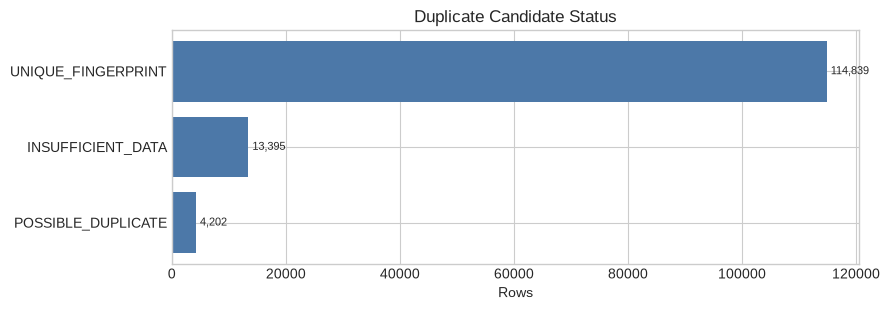

,Value
Candidate Groups,1066
Candidate Listings,4202
Largest Candidate Group,66
Same-source Groups,996
Cross-source Groups,70


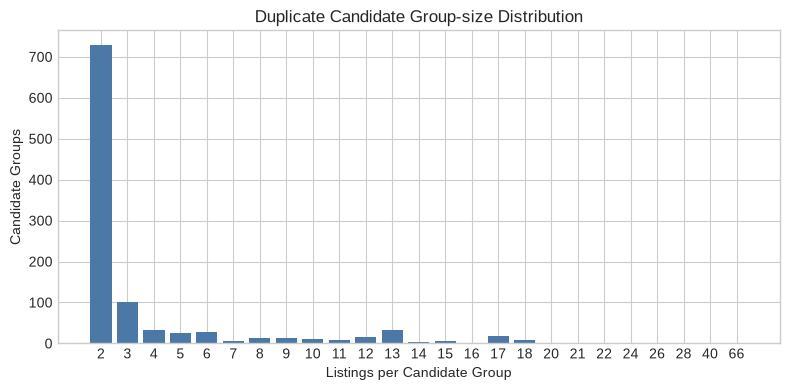

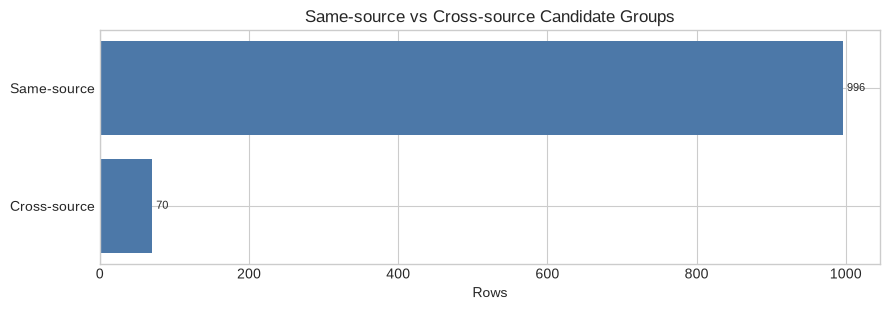

### Same Source Candidate Examples

,duplicate_candidate_group,duplicate_scope,duplicate_match_reason,source_code,source_listing_id,title_clean,price_amount_clean,area_value_clean,best_address_text_clean,ward_current
15,CANDIDATE:b3fd114d287f998c,SAME_SOURCE,EXACT_FINGERPRINT,mogi,22673492,"Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy",1000000.0,45.0,"Nguyễn Kim, Phường 12, Quận 5, TPHCM",Phường Bảy Hiền
25,CANDIDATE:b3fd114d287f998c,SAME_SOURCE,EXACT_FINGERPRINT,mogi,22670492,"Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy",1000000.0,45.0,"Nguyễn Kim, Phường 12, Quận 5, TPHCM",Phường Bảy Hiền
655,CANDIDATE:a6d94dea06fc1ec2,SAME_SOURCE,EXACT_FINGERPRINT,cafeland,3175387,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
656,CANDIDATE:e3c231dfd7d3fff5,SAME_SOURCE,EXACT_FINGERPRINT,cafeland,3175379,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,3500000.0,30.0,Cát Lái TP. Hồ Chí Minh,Phường Cát Lái
665,CANDIDATE:a6d94dea06fc1ec2,SAME_SOURCE,EXACT_FINGERPRINT,cafeland,3174781,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
669,CANDIDATE:e3c231dfd7d3fff5,SAME_SOURCE,EXACT_FINGERPRINT,cafeland,3174717,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,3500000.0,30.0,Cát Lái TP. Hồ Chí Minh,Phường Cát Lái
3467,CANDIDATE:a6d94dea06fc1ec2,SAME_SOURCE,EXACT_FINGERPRINT,cafeland,3171524,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
3468,CANDIDATE:a6d94dea06fc1ec2,SAME_SOURCE,EXACT_FINGERPRINT,cafeland,3171523,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
3533,CANDIDATE:a6d94dea06fc1ec2,SAME_SOURCE,EXACT_FINGERPRINT,cafeland,3165052,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN


### Cross Source Candidate Examples

,duplicate_candidate_group,duplicate_scope,duplicate_match_reason,source_code,source_listing_id,title_clean,price_amount_clean,area_value_clean,best_address_text_clean,ward_current
41,CANDIDATE:29964c1699cd2d9b,CROSS_SOURCE,SAME_TITLE_PRICE_WARD,chothuenha,79960,"CHO THUÊ PHÒNG TRỌ - Khu vực nhà ở quân đội, an ninh yên tĩnh, chính chủ.",6500000.0,NaN,"132 Đường Nguyễn Hữu Cảnh, Phường 22, Quận Bình Thạnh, Hồ Chí Minh",Phường Thạnh Mỹ Tây
166,CANDIDATE:b59c22c30e76045a,CROSS_SOURCE,SAME_TITLE_PRICE_WARD,chothuephongtro,169911,PHÒNG CHO THUÊ Q. TÂN PHÚ 20m2,3500000.0,20.0,"93/9/85 Đường Bờ Bao Tân Thắng, Phường Sơn Kỳ, Tân Phú, Hồ Chí Minh",Phường Tân Sơn Nhì
184,CANDIDATE:af5e964cff530e95,CROSS_SOURCE,SAME_TITLE_PRICE_WARD,chothuephongtro,168948,"Cho nữ thuê phòng trọ 2/4A Nguyễn Thị Minh Khai, Phường Đa Kao trung tâm Quận 1",4000000.0,24.0,"2/4 Đường Nguyễn Thị Minh Khai, Phường Đa Kao, Quận 1, Hồ Chí Minh",Phường Tân Định
1111,CANDIDATE:29964c1699cd2d9b,CROSS_SOURCE,SAME_TITLE_PRICE_WARD,phongtro123,709276,"CHO THUÊ PHÒNG TRỌ - Khu vực nhà ở quân đội, an ninh yên tĩnh, chính chủ.",6500000.0,38.0,"132/115 Đường Nguyễn Hữu Cảnh, Phường Thạnh Mỹ Tây, Hồ Chí Minh",Phường Thạnh Mỹ Tây
2224,CANDIDATE:af5e964cff530e95,CROSS_SOURCE,SAME_TITLE_PRICE_WARD,phongtro123,587873,"Cho nữ thuê phòng trọ 2/4A Nguyễn Thị Minh Khai, Phường Đa Kao trung tâm Quận 1",4000000.0,24.0,"2/4A Đường Nguyễn Thị Minh Khai, Phường Tân Định, Hồ Chí Minh",Phường Tân Định
2344,CANDIDATE:b59c22c30e76045a,CROSS_SOURCE,SAME_TITLE_PRICE_WARD,tromoi,phong-tro/phong-cho-thue-q-tan-phu-20m2,PHÒNG CHO THUÊ Q. TÂN PHÚ 20m2,3500000.0,NaN,"93/9/85, Bờ Bao Tân Thắng, Phường Sơn Kỳ, Quận Tân Phú, Hồ Chí Minh",Phường Tân Sơn Nhì


In [13]:
duplicate_status=status_summary(silver_df.duplicate_candidate_status,'Status'); display(duplicate_status); barh_table(duplicate_status,'Status','Rows','Duplicate Candidate Status')
duplicate_groups,duplicate_distribution=duplicate_group_summary(silver_df)
duplicate_metrics=pd.Series({'Candidate Groups':len(duplicate_groups),'Candidate Listings':int(silver_df.duplicate_candidate_status.eq('POSSIBLE_DUPLICATE').sum()),'Largest Candidate Group':int(duplicate_groups.Listings.max()) if len(duplicate_groups) else 0,'Same-source Groups':int(duplicate_groups['Candidate Scope'].eq('Same-source').sum()) if len(duplicate_groups) else 0,'Cross-source Groups':int(duplicate_groups['Candidate Scope'].eq('Cross-source').sum()) if len(duplicate_groups) else 0},name='Value').to_frame(); display(duplicate_metrics)
if len(duplicate_distribution):
 fig,ax=plt.subplots(figsize=(8,4)); ax.bar(duplicate_distribution['Group Size'].astype(str),duplicate_distribution['Candidate Groups'],color=COLOR); ax.set(title='Duplicate Candidate Group-size Distribution',xlabel='Listings per Candidate Group',ylabel='Candidate Groups'); plt.tight_layout(); plt.show()
 scope=duplicate_groups['Candidate Scope'].value_counts().rename_axis('Scope').reset_index(name='Groups'); barh_table(scope,'Scope','Groups','Same-source vs Cross-source Candidate Groups')
for scope_name in ['SAME_SOURCE','CROSS_SOURCE']:
 ids=silver_df.loc[silver_df.duplicate_scope.eq(scope_name),'duplicate_candidate_group'].dropna().drop_duplicates().head(3)
 sample=silver_df.loc[silver_df.duplicate_candidate_group.isin(ids),['duplicate_candidate_group','duplicate_scope','duplicate_match_reason','source_code','source_listing_id','title_clean','price_amount_clean','area_value_clean','best_address_text_clean','ward_current']]
 display(Markdown(f'### {scope_name.replace("_"," ").title()} Candidate Examples')); display(sample)
if not silver_df.duplicate_scope.eq('CROSS_SOURCE').any(): display(Markdown('**No cross-source candidates were found under the current conservative rules.**'))


## 13. Temporal Semantics Validation

> **Purpose:** Flag timestamp ordering that cannot be safely explained by current evidence.

### Actual Rule
Missing first/last/latest timestamp → `INSUFFICIENT_DATA`. `first > last`, `latest < first`, or `latest > last` → `REQUIRES_REVIEW`; otherwise `VALID`. Cause is not inferred.


,Status,Rows,Percentage (%)
0,VALID,132427,99.99
1,REQUIRES_REVIEW,9,0.01


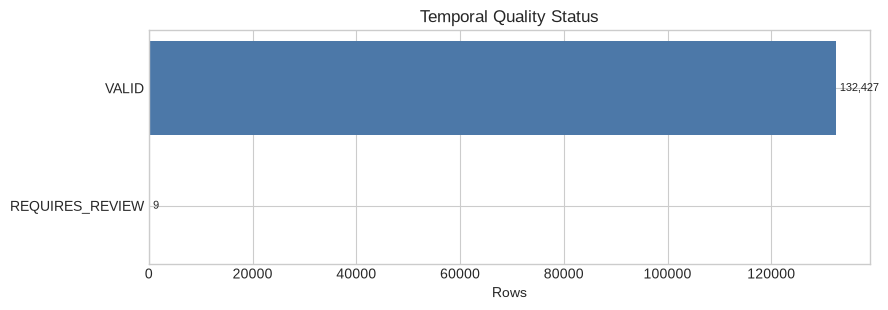

,rental_post_id,source_code,first_observed_at,last_observed_at,latest_observed_at,active_days,temporal_quality_status
736,54334,nhatot,2026-09-20 12:48:36,2026-09-21 12:35:16,2026-09-21 12:41:24,1,REQUIRES_REVIEW
3858,60485,mogi,2026-09-20 13:15:50,2026-09-22 02:55:15,2026-09-22 03:00:15,2,REQUIRES_REVIEW
55240,131725,nhatot,2026-09-21 13:50:28,2026-09-22 12:42:07,2026-09-22 12:46:54,1,REQUIRES_REVIEW
86448,204777,nhatot,2026-09-21 23:37:48,2026-09-22 12:42:07,2026-09-22 12:46:19,1,REQUIRES_REVIEW
118143,268487,nhatot,2026-09-22 12:46:42,2026-09-22 12:42:07,2026-09-22 12:46:42,0,REQUIRES_REVIEW
118145,268491,nhatot,2026-09-22 12:46:51,2026-09-22 12:42:07,2026-09-22 12:46:51,0,REQUIRES_REVIEW
118146,268493,nhatot,2026-09-22 12:46:57,2026-09-22 12:42:07,2026-09-22 12:46:57,0,REQUIRES_REVIEW
118147,268494,nhatot,2026-09-22 12:47:02,2026-09-22 12:42:07,2026-09-22 12:47:02,0,REQUIRES_REVIEW
118148,268495,nhatot,2026-09-22 12:47:03,2026-09-22 12:42:07,2026-09-22 12:47:03,0,REQUIRES_REVIEW


**Remaining Issues:** Requires semantic review; crawler or backfill history is not sufficient here to prove corruption.

In [14]:
temporal_status=status_summary(silver_df.temporal_quality_status,'Status'); display(temporal_status); barh_table(temporal_status,'Status','Rows','Temporal Quality Status')
display(silver_df.loc[silver_df.temporal_quality_status.eq('REQUIRES_REVIEW'),['rental_post_id','source_code','first_observed_at','last_observed_at','latest_observed_at','active_days','temporal_quality_status']].head(15))
display(Markdown('**Remaining Issues:** Requires semantic review; crawler or backfill history is not sufficient here to prove corruption.'))


## 14. Final Row Quality Status

> **Purpose:** Explain the roll-up without converting flags into a quality score.

### Actual Rule
`REQUIRES_REVIEW` remains limited to non-usable title, temporal review, or ambiguous ward mapping. Otherwise `READY_WITH_FLAGS` includes existing flags plus explicit price parser disagreement and Price×Area review states. A disagreement does not automatically become critical review because the existing accepted clean-price contract remains unchanged.


,Row Status,Definition,Rows,Percentage (%)
0,READY,No critical review condition and no configured flags,1267,0.96
1,READY_WITH_FLAGS,"No critical condition, but at least one configured quality flag/unavailable field",129623,97.88
2,REQUIRES_REVIEW,"Non-usable title, temporal review, or ambiguous ward mapping",1546,1.17


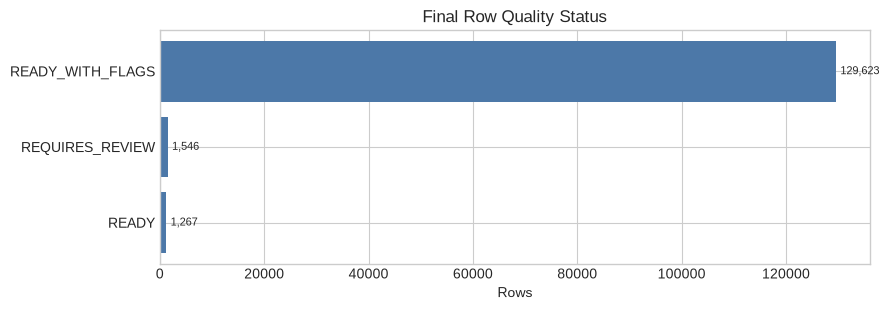

### Top Flag Reasons

,Flag Reason,Affected Rows,Percentage of Dataset (%),Percentage of READY_WITH_FLAGS (%)
0,Coordinate Missing,119587,90.30,91.08
1,Price × Area Review,14056,10.61,10.71
2,Coordinate Untrusted,10572,7.98,8.14
3,Price Parser Disagreement,9513,7.18,7.31
4,Price Outlier,7479,5.65,5.73
5,Area Outlier,5305,4.01,4.08
6,Ward Unmapped / Ambiguous,4950,3.74,3.31
7,Price Review / Unavailable,4385,3.31,3.37
8,Possible Duplicate,4202,3.17,3.22
9,Area Review / Unavailable,2107,1.59,1.61


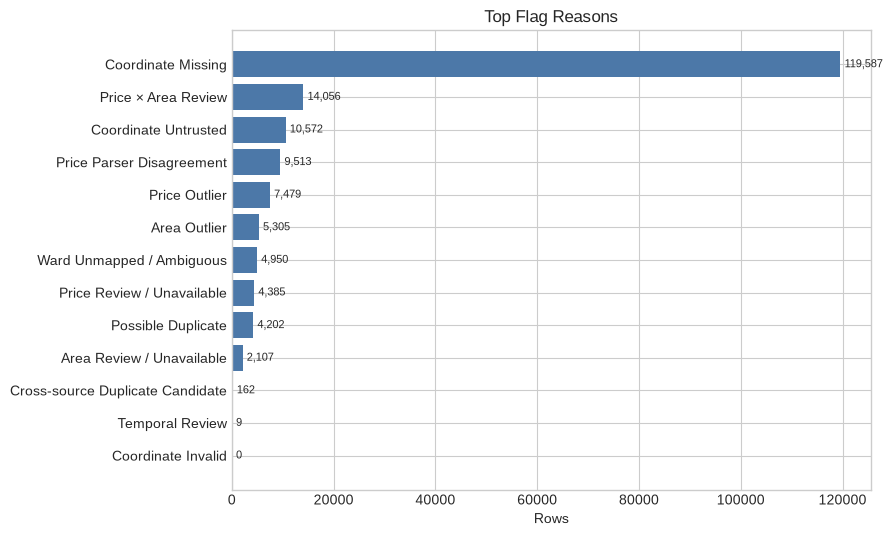

### Number of Flags per Row

,Flag Count,Rows,Percentage (%)
0,0,1180,0.89
1,1,96280,72.70
2,2,21318,16.10
3,3,11503,8.69
4,4+,2155,1.63


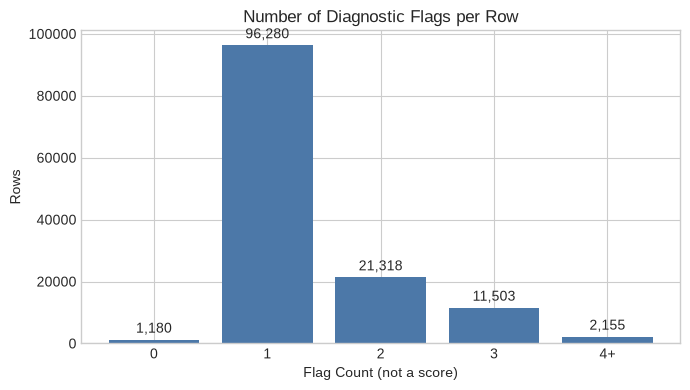

In [15]:
row_status=status_summary(silver_df.row_quality_status,'Row Status')
row_defs=pd.DataFrame([['READY','No critical review condition and no configured flags'],['READY_WITH_FLAGS','No critical condition, but at least one configured quality flag/unavailable field'],['REQUIRES_REVIEW','Non-usable title, temporal review, or ambiguous ward mapping']],columns=['Row Status','Definition']).merge(row_status,on='Row Status',how='left'); display(row_defs); barh_table(row_status,'Row Status','Rows','Final Row Quality Status')
display(Markdown('### Top Flag Reasons'))
flag_breakdown,flag_matrix=flag_reason_breakdown(silver_df); display(flag_breakdown)
barh_table(flag_breakdown.head(15),'Flag Reason','Affected Rows','Top Flag Reasons')
display(Markdown('### Number of Flags per Row'))
flag_distribution=multi_flag_distribution(flag_matrix); display(flag_distribution)
fig,ax=plt.subplots(figsize=(7,4)); bars=ax.bar(flag_distribution['Flag Count'],flag_distribution.Rows,color=COLOR); ax.set(title='Number of Diagnostic Flags per Row',xlabel='Flag Count (not a score)',ylabel='Rows'); ax.bar_label(bars,fmt='{:,.0f}',padding=3); plt.tight_layout(); plt.show()


## 15. Silver Dataset Contract and Raw → Silver Lineage Examples

> **Purpose:** Make every output field and representative transformation trace readable.


In [16]:
def field_group(field):
 if field in ['source_code','rental_post_id','source_listing_id','url']: return 'Identity'
 if 'title' in field: return 'Title'
 if 'price' in field: return 'Price'
 if 'area' in field: return 'Area'
 if field in ['full_address_text','location_raw','best_address_text','best_address_source','full_address_inherited'] or 'address' in field or field in ['street_text_extracted','parse_status']: return 'Address'
 if 'ward' in field or 'district' in field or 'province' in field: return 'Administrative Location'
 if field.startswith('map_') or 'coordinate' in field or field=='has_trusted_coordinate': return 'Coordinate'
 if 'duplicate' in field: return 'Duplicate'
 if 'observed' in field or field=='active_days' or 'temporal' in field: return 'Temporal'
 if 'quality' in field or 'outlier' in field or 'cross_field' in field: return 'Quality'
 if 'lineage' in field or 'regression' in field: return 'Lineage'
 return 'Other'
def field_kind(field):
 if field in BRONZE_COLUMNS: return 'Raw'
 if field.endswith('_status') or field.endswith('_flag') or field in ['parse_status','has_trusted_coordinate']: return 'Status'
 return 'Clean / Derived'
contract_rows=[]
for field in silver_df.columns:
 contract_rows.append({'Group':field_group(field),'Field':field,'Origin':'Bronze snapshot' if field in BRONZE_COLUMNS else 'Canonical Silver helper','Meaning':field.replace('_',' ').title(),'Raw / Clean / Status':field_kind(field),'Nullable?':'Yes' if silver_df[field].isna().any() else 'No','Notes':'Raw preserved unchanged' if field in BRONZE_COLUMNS else 'See rule section above'})
silver_contract=pd.DataFrame(contract_rows).sort_values(['Group','Field']); display(silver_contract)
selectors=[('Normal Clean',silver_df.row_quality_status.eq('READY')),('Price Reparse',silver_df.price_quality_status.eq('REPARSE_ACCEPTED_CLEAN')),('Ward Mapped',silver_df.ward_mapping_status.eq('MAPPED')),('Coordinate Review',~silver_df.has_trusted_coordinate),('Duplicate Candidate',silver_df.duplicate_candidate_status.eq('POSSIBLE_DUPLICATE')),('Temporal Review',silver_df.temporal_quality_status.eq('REQUIRES_REVIEW'))]
chosen=[]
for label,mask in selectors:
 for idx in silver_df.index[mask]:
  if idx not in chosen: chosen.append(idx); break
lineage=silver_df.loc[chosen,['rental_post_id','source_code','title_raw','title_clean','price_amount','price_amount_clean','area_value','area_value_clean','best_address_text','best_address_text_clean','ward_text_extracted','ward_current','coordinate_trust_reason','duplicate_candidate_status','temporal_quality_status','row_quality_status']].copy()
lineage.insert(0,'Lineage Example',[next((label for label,mask in selectors if bool(mask.loc[idx])), 'Representative') for idx in chosen])
display(Markdown('### Raw → Silver Lineage Examples')); display(lineage)


,Group,Field,Origin,Meaning,Raw / Clean / Status,Nullable?,Notes
15,Address,best_address_source,Bronze snapshot,Best Address Source,Raw,No,Raw preserved unchanged
14,Address,best_address_text,Bronze snapshot,Best Address Text,Raw,Yes,Raw preserved unchanged
22,Address,best_address_text_clean,Canonical Silver helper,Best Address Text Clean,Clean / Derived,Yes,See rule section above
59,Address,coordinate_pair_address_count,Canonical Silver helper,Coordinate Pair Address Count,Clean / Derived,No,See rule section above
9,Address,full_address_inherited,Bronze snapshot,Full Address Inherited,Raw,No,Raw preserved unchanged
...,...,...,...,...,...,...,...
16,Temporal,latest_observed_at,Bronze snapshot,Latest Observed At,Raw,No,Raw preserved unchanged
69,Temporal,temporal_quality_status,Canonical Silver helper,Temporal Quality Status,Status,No,See rule section above
23,Title,title_clean,Canonical Silver helper,Title Clean,Clean / Derived,Yes,See rule section above
24,Title,title_quality_status,Canonical Silver helper,Title Quality Status,Status,No,See rule section above


### Raw → Silver Lineage Examples

,Lineage Example,rental_post_id,source_code,title_raw,title_clean,price_amount,price_amount_clean,area_value,area_value_clean,best_address_text,best_address_text_clean,ward_text_extracted,ward_current,coordinate_trust_reason,duplicate_candidate_status,temporal_quality_status,row_quality_status
71,Normal Clean,53669,cafeland,Cho Thuê Phòng Cao Cấp Đầy Đủ Tiện Nghi Tại Q9 2tr7,Cho Thuê Phòng Cao Cấp Đầy Đủ Tiện Nghi Tại Q9 2tr7,2700000.0,2.700000e+06,18.0,18.0,"25/16/1, , Tăng Nhơn Phú TP. Hồ Chí Minh","25/16/1, Tăng Nhơn Phú TP. Hồ Chí Minh",Phường Tăng Nhơn Phú,Phường Tăng Nhơn Phú,TRUSTED_UNIQUE_POINT,UNIQUE_FINGERPRINT,VALID,READY
36966,Price Reparse,99659,cafeland,"Phòng trọ: Bán nhà MT Nguyễn Đình Chiểu P, 6 Quận 3, dt:20x18m giá 275 tỷ","Phòng trọ: Bán nhà MT Nguyễn Đình Chiểu P, 6 Quận 3, dt:20x18m giá 275 tỷ",NaN,2.750000e+11,330.0,330.0,Xuân Hòa TP. Hồ Chí Minh,Xuân Hòa TP. Hồ Chí Minh,Phường Xuân Hòa,Phường Xuân Hòa,SHARED_POINT_CONFLICTING_ADDRESSES,UNIQUE_FINGERPRINT,VALID,READY_WITH_FLAGS
43,Ward Mapped,53641,chothuephongtro,"Cho thuê phòng trọ ở Q7, đường Trần Văn Khánh, di chuyển dễ dàng Q7, Q4, Q1","Cho thuê phòng trọ ở Q7, đường Trần Văn Khánh, di chuyển dễ dàng Q7, Q4, Q1",2400000.0,2.400000e+06,18.0,18.0,"Đường Trần Văn Khánh, Phường Tân Thuận Đông, Quận 7, Hồ Chí Minh","Đường Trần Văn Khánh, Phường Tân Thuận Đông, Quận 7, Hồ Chí Minh",Phường Tân Thuận Đông,Phường Tân Thuận,MISSING_COORDINATE_PAIR,UNIQUE_FINGERPRINT,VALID,READY_WITH_FLAGS
0,Coordinate Review,53598,mogi,Cho Thuê Phòng Q3 rộng rãi thoải mái.cửa sổ nội thất 3tr1,Cho Thuê Phòng Q3 rộng rãi thoải mái.cửa sổ nội thất 3tr1,3000000.0,3.000000e+06,16.0,16.0,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), Quận 3, TPHCM","Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), Quận 3, TPHCM",Xã Bình Hưng,NaN,SHARED_POINT_CONFLICTING_ADDRESSES,UNIQUE_FINGERPRINT,VALID,READY_WITH_FLAGS
15,Coordinate Review,53613,mogi,"Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy","Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy",1000000.0,1.000000e+06,45.0,45.0,"Nguyễn Kim, Phường 12, Quận 5, TPHCM","Nguyễn Kim, Phường 12, Quận 5, TPHCM",Phường Bảy Hiền,Phường Bảy Hiền,SHARED_POINT_CONFLICTING_ADDRESSES,POSSIBLE_DUPLICATE,VALID,READY_WITH_FLAGS
736,Coordinate Review,54334,nhatot,NaN,None,4500000.0,4.500000e+06,20.0,20.0,"duong So 17, Phường 11, Quận Gò Vấp, Tp Hồ Chí Minh","duong So 17, Phường 11, Quận Gò Vấp, Tp Hồ Chí Minh",Phường Bảy Hiền,Phường Bảy Hiền,MISSING_COORDINATE_PAIR,UNIQUE_FINGERPRINT,REQUIRES_REVIEW,REQUIRES_REVIEW


## 16. Pre-Silver Quality Gate

> **Purpose:** Stop publication when grain, identity, lineage, clean-value, or documented-status invariants fail.

The asserts remain authoritative and materialization has not occurred before this section.


,Invariant,PASS / FAIL,What It Protects
0,row_count_preserved,PASS,Protects against silent row deletion
1,rental_post_id_non_null,PASS,Protects identity completeness
2,rental_post_id_unique,PASS,Protects one-row grain
3,source_identity_preserved,PASS,Protects source identity
4,raw_source_fields_unchanged,PASS,Protects Bronze/source lineage
5,no_row_multiplication_or_deletion,PASS,Protects join cardinality
6,price_clean_contract_valid,PASS,Protects price acceptance rules
7,area_clean_contract_valid,PASS,Protects area acceptance rules
8,ambiguous_ward_not_truth,PASS,Prevents guessed administrative mapping
9,invalid_coordinates_not_usable,PASS,Protects spatial trust


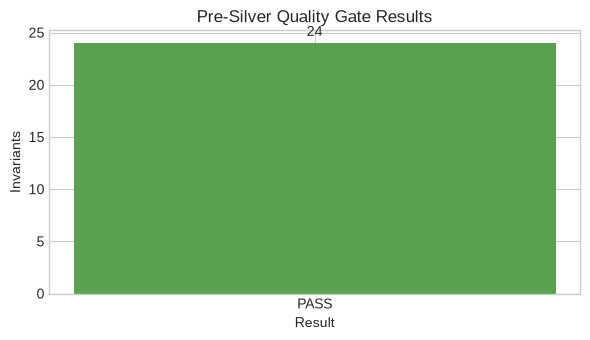

In [17]:
quality_gate=evaluate_pre_silver_quality_gate(RAW_FINGERPRINT,silver_df)
protections={'row_count_preserved':'Protects against silent row deletion','rental_post_id_non_null':'Protects identity completeness','rental_post_id_unique':'Protects one-row grain','source_identity_preserved':'Protects source identity','raw_source_fields_unchanged':'Protects Bronze/source lineage','no_row_multiplication_or_deletion':'Protects join cardinality','price_clean_contract_valid':'Protects price acceptance rules','area_clean_contract_valid':'Protects area acceptance rules','ambiguous_ward_not_truth':'Prevents guessed administrative mapping','invalid_coordinates_not_usable':'Protects spatial trust','outliers_preserved_and_flagged':'Prevents silent outlier deletion','duplicate_candidates_preserved_and_flagged':'Prevents silent candidate deletion','price_parser_disagreement_preserved':'Keeps parser disagreements explicit','price_area_status_domain_valid':'Protects Price × Area status domains','duplicate_scope_domain_valid':'Protects duplicate scope vocabulary','duplicate_candidate_rows_preserved':'Prevents candidate-driven row deletion','cross_source_duplicate_rule_deterministic':'Protects conservative cross-source rule semantics','documented_status_values_only':'Protects status contract'}
quality_gate_frame=quality_gate.to_frame().rename(columns={'invariant':'Invariant','passed':'Passed'})
quality_gate_frame['PASS / FAIL']=np.where(quality_gate_frame.Passed,'PASS','FAIL'); quality_gate_frame['What It Protects']=quality_gate_frame.Invariant.map(protections)
display(quality_gate_frame[['Invariant','PASS / FAIL','What It Protects']])
gate_counts=quality_gate_frame['PASS / FAIL'].value_counts().rename_axis('Result').reset_index(name='Invariants')
fig,ax=plt.subplots(figsize=(6,3.5)); bars=ax.bar(gate_counts.Result,gate_counts.Invariants,color=[OK if x=='PASS' else REVIEW for x in gate_counts.Result]); ax.set(title='Pre-Silver Quality Gate Results',xlabel='Result',ylabel='Invariants'); ax.bar_label(bars,padding=3); plt.tight_layout(); plt.show()
assert quality_gate.passed


## 17. Compare with Published Canonical Silver (Read-only)

> **Purpose:** Verify that the canonical `data/silver/rental_listings.parquet` published by the Airflow DAG `roombeacon_silver_build` matches this notebook's in-memory rebuild of the same Bronze snapshot.

```text
roombeacon_bronze_snapshot (Airflow, bounded MySQL read)
    ↓ Asset: bronze_snapshot
roombeacon_silver_build → roombeacon_processing.build.build_silver()
    ↓
data/silver/rental_listings.parquet (+ metadata)
    ↓ read-only
this notebook: row-hash parity audit
```

This notebook never writes, replaces or deletes Silver files.


In [ ]:
assert quality_gate.passed

# Read-only audit. Canonical Silver is published only by the Airflow DAG
# roombeacon_silver_build (roombeacon_processing.build.build_silver), which runs
# after roombeacon_bronze_snapshot emits the bronze_snapshot Asset.
from roombeacon_processing.golden import aggregate_row_hashes, hash_silver_rows

SILVER_DIR = resolve_runtime_path(env.processing.silver_dir)
SILVER_PATH = SILVER_DIR / 'rental_listings.parquet'
METADATA_PATH = SILVER_DIR / 'rental_listings.metadata.json'
if not (SILVER_PATH.is_file() and METADATA_PATH.is_file()):
    raise FileNotFoundError(
        'Canonical Silver is not published yet. Trigger the Airflow DAG '
        'roombeacon_bronze_snapshot; roombeacon_silver_build publishes Silver.'
    )

published_metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8'))
published_snapshot_id = (published_metadata.get('source_snapshot') or {}).get('snapshot_id')
if published_snapshot_id != RUN_CONTEXT['snapshot_id']:
    raise RuntimeError(
        f"Published Silver was built from snapshot {published_snapshot_id}, but this notebook "
        f"audits snapshot {RUN_CONTEXT['snapshot_id']}. Wait for roombeacon_silver_build to "
        "finish for the current snapshot; notebooks never publish Silver."
    )

published_silver_df = conn.execute('SELECT * FROM read_parquet(?)', [str(SILVER_PATH)]).df()
assert list(published_silver_df.columns) == list(silver_df.columns)
assert len(published_silver_df) == len(silver_df)
published_rows_sha256 = aggregate_row_hashes(
    hash_silver_rows(published_silver_df.sort_values('rental_post_id', kind='stable'))
)
in_memory_rows_sha256 = aggregate_row_hashes(
    hash_silver_rows(silver_df.sort_values('rental_post_id', kind='stable'))
)
assert published_rows_sha256 == in_memory_rows_sha256, (
    'Published Silver differs from the in-memory rebuild of the same snapshot'
)

parity_summary = pd.Series({
    'Canonical Silver Path': str(SILVER_PATH),
    'Published By': 'Airflow DAG roombeacon_silver_build',
    'Source Snapshot ID': published_snapshot_id,
    'Rows': len(published_silver_df),
    'Columns': len(published_silver_df.columns),
    'Published Output SHA-256': published_metadata.get('output_sha256'),
    'Row-hash Parity': 'MATCH',
}, name='Value').to_frame()
display(parity_summary)


## 18. Final Silver Validation and Health Summary

> **Purpose:** Independently read the canonical Parquet checkpoint, verify row/identity/schema parity, and answer: “After Processing, what problems still remain in Silver?”

,row_count,distinct_rental_post_id,column_count,validation_status
0,132436,132436,71,PASS


### Final Silver Health Summary

,Quality Dimension,Healthy / Available,Flagged / Review,Missing / Unavailable,Notes
0,Title,131297,650,489,Structural title usability
1,Price,128051,7479,4385,Validated or safe recovery only
2,Area,130329,5305,2107,Validated or safe recovery only
3,Address,45791,77703,8942,"Parser evidence, not official truth"
4,Ward Mapping,110840,4950,16646,Internal RoomBeacon reference
5,Coordinates,2277,10572,119587,Missing is separate from invalid/untrusted
6,Price × Area,111908,14056,6472,Availability and deterministic audit flags are separate
7,Duplicate,114839,4202,13395,Candidates are not confirmations
8,Temporal,132427,9,0,Review cause is not inferred


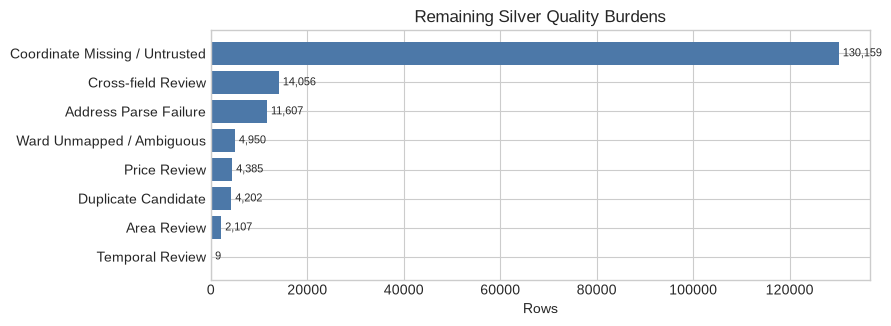

In [19]:
silver_sql_path = str(SILVER_PATH).replace("'", "''")
canonical_silver_df = conn.execute(
    f"SELECT * FROM read_parquet('{silver_sql_path}')"
).df()
assert len(canonical_silver_df) == len(silver_df)
assert canonical_silver_df.rental_post_id.notna().all()
assert canonical_silver_df.rental_post_id.nunique() == len(canonical_silver_df)
assert list(canonical_silver_df.columns) == list(silver_df.columns)
assert {'rental_post_id', 'source_code', 'price_parser_comparison_status'} <= set(canonical_silver_df.columns)
assert METADATA_PATH.exists()

canonical_summary = pd.DataFrame([{
    'row_count': len(canonical_silver_df),
    'distinct_rental_post_id': canonical_silver_df.rental_post_id.nunique(),
    'column_count': len(canonical_silver_df.columns),
    'validation_status': 'PASS',
}])
display(canonical_summary)

health=pd.DataFrame([
 ['Title',silver_df.title_quality_status.eq('USABLE').sum(),silver_df.title_quality_status.eq('TOO_SHORT').sum(),silver_df.title_quality_status.eq('MISSING').sum(),'Structural title usability'],
 ['Price',silver_df.price_amount_clean.notna().sum(),silver_df.price_outlier_flag.sum(),silver_df.price_amount_clean.isna().sum(),'Validated or safe recovery only'],
 ['Area',silver_df.area_value_clean.notna().sum(),silver_df.area_outlier_flag.sum(),silver_df.area_value_clean.isna().sum(),'Validated or safe recovery only'],
 ['Address',silver_df.parse_status.eq('PARSED').sum(),silver_df.parse_status.isin(['PARTIALLY_PARSED','UNRECOGNIZED_FORMAT']).sum(),silver_df.parse_status.eq('NO_ADDRESS_EVIDENCE').sum(),'Parser evidence, not official truth'],
 ['Ward Mapping',silver_df.ward_current.notna().sum(),silver_df.ward_mapping_status.isin(['UNMAPPED','AMBIGUOUS']).sum(),silver_df.ward_mapping_status.eq('MISSING').sum(),'Internal RoomBeacon reference'],
 ['Coordinates',silver_df.has_trusted_coordinate.sum(),silver_df.coordinate_trust_reason.ne('MISSING_COORDINATE_PAIR').sum()-silver_df.has_trusted_coordinate.sum(),silver_df.coordinate_trust_reason.eq('MISSING_COORDINATE_PAIR').sum(),'Missing is separate from invalid/untrusted'],
 ['Price × Area',silver_df.price_area_quality_status.eq('CHECKED_NO_FLAG').sum(),silver_df.price_area_quality_status.str.endswith('REVIEW').sum(),silver_df.price_area_quality_status.eq('INSUFFICIENT_DATA').sum(),'Availability and deterministic audit flags are separate'],
 ['Duplicate',silver_df.duplicate_candidate_status.eq('UNIQUE_FINGERPRINT').sum(),silver_df.duplicate_candidate_status.eq('POSSIBLE_DUPLICATE').sum(),silver_df.duplicate_candidate_status.eq('INSUFFICIENT_DATA').sum(),'Candidates are not confirmations'],
 ['Temporal',silver_df.temporal_quality_status.eq('VALID').sum(),silver_df.temporal_quality_status.eq('REQUIRES_REVIEW').sum(),silver_df.temporal_quality_status.eq('INSUFFICIENT_DATA').sum(),'Review cause is not inferred'],
],columns=['Quality Dimension','Healthy / Available','Flagged / Review','Missing / Unavailable','Notes']); display(Markdown('### Final Silver Health Summary')); display(health)
review_burden=pd.DataFrame({'Remaining Issue':['Price Review','Area Review','Address Parse Failure','Ward Unmapped / Ambiguous','Coordinate Missing / Untrusted','Duplicate Candidate','Temporal Review','Cross-field Review'],'Rows':[silver_df.price_quality_status.isin(['MISSING_OR_REVIEW','UNKNOWN_LINEAGE']).sum(),silver_df.area_quality_status.isin(['MISSING_OR_REVIEW','UNKNOWN_LINEAGE']).sum(),silver_df.parse_status.isin(['UNRECOGNIZED_FORMAT','NO_ADDRESS_EVIDENCE']).sum(),silver_df.ward_mapping_status.isin(['UNMAPPED','AMBIGUOUS']).sum(),(~silver_df.has_trusted_coordinate).sum(),silver_df.duplicate_candidate_status.eq('POSSIBLE_DUPLICATE').sum(),silver_df.temporal_quality_status.eq('REQUIRES_REVIEW').sum(),silver_df.price_area_quality_status.str.endswith('REVIEW').sum()]})
barh_table(review_burden,'Remaining Issue','Rows','Remaining Silver Quality Burdens')
pd.testing.assert_frame_equal(silver_df[BRONZE_COLUMNS],RAW_FINGERPRINT)
conn.close()